# RE-MANGLE spectra
We need to re-mangle spectra because what we did in the 2dim fitting is "in principle" wrong.

In the 2dim grid we compared synthetic photometry @ average filter wavelength with Flux spectral density.
You should use eff wavelength, which is avg filter wavelength weighted for the underlying SED.

Now that we have extrapolated an approximated estimate of the underlying SEDs we need to iterativly warp&re-measure eff wvl of the SED until observed photometry and synthesized photometry is matching.

Read Section 2.2.2 of the paper if you are confused!!

    

In [1]:
import os
#COCO_PATH=os.environ['COCO_PATH']
COCO_PATH="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/"
DATALC_PATH = COCO_PATH+"/Inputs/Photometry/4_LCs_late_extrapolated/"
DATASPEC_PATH = COCO_PATH+"/Inputs/Spectroscopy/"

DATAINFO_PATH= COCO_PATH+"Inputs/SNe_Info/"
FILTER_PATH = COCO_PATH+"Inputs/Filters/"

OUTPUT_DIR = COCO_PATH+"Outputs/"

import sys
sys.path.insert(0, COCO_PATH+'what_the_flux/')
import what_the_flux as wtf
sys.path.insert(0, COCO_PATH+'Codes/')
import rimangle_log_spectrum as rml
import pipeline_config as pconf
from comparison_check_log_utils import twodim_final_branch

# Match notebook 6: spec_class.mode ('extend_spectra' | 'extrapolate_spectra') and dual product (spliced | full_gp).
TWODIM_GP_MODE_RIMANGLE = 'extrapolate_spectra'
TWODIM_PRODUCT_RIMANGLE = pconf.SUBDIR_FULL_GP


def twodim_extended_spectra_path(sn):
    return pconf.twodim_product_dir(OUTPUT_DIR, sn, TWODIM_GP_MODE_RIMANGLE, TWODIM_PRODUCT_RIMANGLE) + '/'


def final_spectra_path_2dim(sn):
    if pconf.USE_LEGACY_TWODIM_LAYOUT:
        base = pconf.final_spectra_branch_dir(COCO_PATH.rstrip(os.sep), sn, twodim_branch=None)
    else:
        br = twodim_final_branch(
            pconf.twodim_mode_to_short(TWODIM_GP_MODE_RIMANGLE),
            TWODIM_PRODUCT_RIMANGLE,
        )
        base = pconf.final_spectra_branch_dir(COCO_PATH.rstrip(os.sep), sn, twodim_branch=br)
    return base + os.sep


In [2]:
import numpy as np
import json
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os
import pandas as pd
from astropy.io import fits
from scipy import interpolate
from scipy import integrate
import scipy.optimize as opt
import sncosmo

import matplotlib.cm as cm
import scipy
from itertools import cycle

import george
from george.kernels import ExpSquaredKernel, ConstantKernel, Matern32Kernel

import astropy.units as u
%matplotlib inline

In [3]:
### I NEED TO ASSUME SOME COSMOLOGY IF I WANT TO GET ABSOLUTE FLUX TEMPLATES (AS IF THEY WERE AT 10pc)
import astropy.cosmology
mycosmo = astropy.cosmology.FlatLambdaCDM(Om0=0.3, H0=70)

In [4]:
color_dict = {'Bessell_U': 'blue', 'Bessell_B': 'royalblue','Bessell_V':  'limegreen',
              'Bessell_R':  'red', 'Bessell_I':  'mediumvioletred',
              'sdss_g':'darkgreen','ptf_g':'darkgreen', "sdss_g'":'darkgreen','sdss_i':'indianred',
              "sdss_i'":'indianred','sdss_r': 'darkred', "sdss_r'":'darkred','sdss_z':'sienna', "sdss_z'":'sienna',
              'sdss_u': 'darkblue', "sdss_u'": 'darkblue', 'Y':'salmon','H':'darkred', 'J':  'k',
              'Ks':  'brown','K':  'brown', 'swift_UVW1':'indigo', 'swift_UVW2':'darkblue',
               'swift_UVM2':'darkmagenta','swift_U':'plum','swift_V':'teal','swift_B':'powderblue'}

mark_dict = {'Bessell_U': 'o','Bessell_B': 'o', 'Bessell_V':'o', 'Bessell_R':'o', 'Bessell_I': 'o', 
             'sdss_g':'s','ptf_g':'s', "sdss_g'":'s', 'sdss_i':'s', "sdss_i'":'s',
                'sdss_r':'s', "sdss_r'":'s', 'sdss_z':'s', "sdss_z'":'s', 'sdss_u': 's', "sdss_u'": 's',
                'Y':  'o','H':  'o', 'J':  'o', 'Ks':  'o','K':  'o',
                'swift_UVW1':'D', 'swift_UVW2':'D', 'swift_UVM2':'D', 'swift_U':'D',
                'swift_V':'D', 'swift_B':'D'}

CSP_SNe = ['SN2004fe', 'SN2005bf', 'SN2006V', 'SN2007C', 'SN2007Y',
           'SN2009bb',  'SN2008aq', 'SN2006T', 'SN2004gq', 'SN2004gt',
           'SN2004gv','SN2006ep', 'SN2008fq', 'SN2006aa']

#exclude_filt = ['H', 'J', 'K', 'Ks','KS', 'Y']

convert2mjd = (lambda x: float(x.replace('_spec_extended.txt','')\
                               .replace('_spec_extended_FL.txt','')\
                               .replace('_spec_extended_SMOOTH.txt','')))

#exclude_filt = ['H','Ks', 'J', 'K']

In [5]:
color_dict = {
    # Existing matches from your example
    'Swope_i': 'indianred',
    'FourStar_H': 'darkred',
    'FourStar_J': 'black',
    'DECam_i': 'orangered',
    'DECam_z': 'darkslategray',
    'DECam_Y': 'goldenrod',
    'FourStar_Ks': 'brown',
    'UVOT_U': 'teal',
    'Skymapper_i': 'slateblue',
    'Sinistro_g': 'darkgreen',
    'Sinistro_r': 'crimson',
    'Skymapper_r': 'deeppink',
    'Skymapper_g': 'forestgreen',
    'EFOSC2_V': 'limegreen',
    'Sinistro_i': 'firebrick',
    'DECam_r': 'darkorange',
    'DECam_g': 'mediumspringgreen',
    'DECam_u': 'navy',
    'Swope_V': 'green',
    'FourStar_J1': 'dimgray',
    'Swope_B': 'royalblue',
    'Swope_r': 'red',
    'Swope_g': 'darkseagreen',
    'EFOSC2_U': 'blue',
    'Sinistro_V': 'mediumaquamarine',
    'Sinistro_z': 'sienna',
    'IMACS_r': 'darkred',
    'LRIS_I': 'mediumvioletred',
    'SOFI_H': 'firebrick',
    'SOFI_Ks': 'saddlebrown',

    # New assignments (color-coded by band)
    'VISTA_Ks': 'saddlebrown',
    'VISTA_J': 'dimgray',
    'VISTA_Y': 'salmon',
    'FLAMINGOS-2_Ks': 'sienna',
    'UVOT_M2': 'darkviolet',
    'UVOT_W1': 'purple',
    'UVOT_W2': 'indigo',
    'HSC_z': 'darkslategray',
    'GFC_i': 'firebrick',
    'GFC_y': 'goldenrod',
    'GFC_z': 'maroon',
    'GFC_r': 'tomato',
    'SIRIUS_H': 'darkred',
    'SIRIUS_J': 'black',
    'SIRIUS_Ks': 'brown',
    'T80Cam_g': 'seagreen',
    'GROND_H': 'maroon',
    'GROND_J': 'dimgray',
    'GROND_K': 'saddlebrown',
    'GROND_g': 'mediumseagreen',
    'GROND_i': 'orangered',
    'GROND_r': 'crimson',
    'GROND_z': 'darkslategray',
    'DECam_Y': 'goldenrod',
    'FLAMINGOS-2_H': 'firebrick',
    'IMACS_i': 'orangered',
    'FLAMINGOS-2_J': 'black',
    'UVOT_B': 'dodgerblue',
    'GMOS_g': 'green',
    'GMOS_i': 'indianred',
    'GMOS_r': 'red',
    'GMOS_z': 'darkslategray',
    'FORS2_R': 'crimson',
    'VIMOS_z': 'maroon',
    'FORS2_I': 'mediumvioletred',
    'FORS2_B': 'blue',
    'FORS2_V': 'limegreen',
    'ANDICAM_K': 'brown',
    'MOIRCS_Ks': 'sienna',
    'HAWKI_Ks': 'brown'
}

exclude_filt = []
#exclude_filt = ['H', 'J', 'K', 'Ks','KS', 'Y', 'FourStar_H', 'FourStar_J', 'FourStar_Ks', 'FourStar_J1',
#                'RetroCam_Y', 'RetroCam_H', 'RetroCam_J', 'SOFI_H', 'SOFI_Ks']

mark_dict = {
    # Swope (Circle)
    'Swope_i': 'o',
    'Swope_V': 'o',
    'Swope_B': 'o',
    'Swope_r': 'o',
    'Swope_g': 'o',

    # FourStar (Circle)
    'FourStar_H': 'o',
    'FourStar_J': 'o',
    'FourStar_Ks': 'o',
    'FourStar_J1': 'o',
    'FourStar_Ks': 'o',

    # VISTA (Circle - keeping consistent with other IR survey survey data)
    'VISTA_Ks': 'o',
    'VISTA_J': 'o',
    'VISTA_Y': 'o',

    # SOFI (Circle)
    'SOFI_H': 'o',
    'SOFI_Ks': 'o',

    # ANDICAM (Circle)
    'ANDICAM_K': 'o',

    # DECam (Triangle Up)
    'DECam_i': '^',
    'DECam_z': '^',
    'DECam_Y': '^',
    'DECam_r': '^',
    'DECam_g': '^',
    'DECam_u': '^',

    # HSC (Triangle Right - distinct from DECam but similar large imager)
    'HSC_z': '>',

    # MOIRCS (Triangle Right - Subaru)
    'MOIRCS_Ks': '>',

    # FLAMINGOS-2 (Triangle Down - Gemini IR)
    'FLAMINGOS-2_Ks': 'v',
    'FLAMINGOS-2_H': 'v',
    'FLAMINGOS-2_J': 'v',

    # GMOS (Triangle Left - Gemini Optical)
    'GMOS_g': '<',
    'GMOS_i': '<',
    'GMOS_r': '<',
    'GMOS_z': '<',

    # FORS2 (Triangle Left - VLT)
    'FORS2_R': '<',
    'FORS2_I': '<',
    'FORS2_B': '<',
    'FORS2_V': '<',

    # VIMOS (Triangle Left - VLT)
    'VIMOS_z': '<',

    # HAWKI (Triangle Left - VLT)
    'HAWKI_Ks': '<',

    # UVOT (Cross)
    'UVOT_M2': 'X',
    'UVOT_W1': 'X',
    'UVOT_U': 'X',
    'UVOT_W2': 'X',
    'UVOT_B': 'X',

    # GFC / Pan-STARRS (Pentagon)
    'GFC_i': 'p',
    'GFC_y': 'p',
    'GFC_z': 'p',
    'GFC_r': 'p',

    # Skymapper (Plus Filled)
    'Skymapper_i': 'P',
    'Skymapper_r': 'P',
    'Skymapper_g': 'P',

    # Sinistro (Square)
    'Sinistro_g': 's',
    'Sinistro_r': 's',
    'Sinistro_i': 's',
    'Sinistro_V': 's',
    'Sinistro_z': 's',

    # IMACS (Square)
    'IMACS_i': 's',
    'IMACS_r': 's',

    # SIRIUS (Diamond - grouped with other medium aperture IR like SOFI/RetroCam? or Diamond like EFOSC2)
    'SIRIUS_H': 'D',
    'SIRIUS_J': 'D',
    'SIRIUS_Ks': 'D',

    # EFOSC2 (Diamond)
    'EFOSC2_V': 'D',
    'EFOSC2_U': 'D',

    # LRIS (Diamond)
    'LRIS_I': 'D',

    # T80Cam (Star - distinct small survey)
    'T80Cam_g': '*',

    # GROND (Hexagon - multi-channel instrument)
    'GROND_H': 'h',
    'GROND_J': 'h',
    'GROND_K': 'h',
    'GROND_g': 'h',
    'GROND_i': 'h',
    'GROND_r': 'h',
    'GROND_z': 'h'
}

In [6]:
info_objects = pd.read_csv(DATAINFO_PATH+'info.dat', comment='#', delimiter=' ')

In [7]:
def calc_lam_eff(wls, transmission, flux):
    return (integrate.trapezoid(transmission*flux*wls, wls)/\
            integrate.trapezoid(transmission*flux, wls))

def prop_err_div(x,y,sig_x,sig_y):
    return ((sig_x/y)**2  +  ((x*sig_y)/y**2)**2 )**0.5

In [8]:
import numpy as np

class ReMangle_SingleSpectrumClass():
    """Class to load and mangle a single spectrum:
    """
    
    def __init__(self, snname, twodim=True, spec_file=None, verbose=False, extended_flux_in_log10=None, save_flux_in_log10=True):
        """
        extended_flux_in_log10: None=auto (NB6 newlog: linear Å, log10 F on disk), True/False=override.
        save_flux_in_log10: if True and extended was log10, REmangled output columns are log10 F / dex (same as extended files).
        """
        ## Initialise the class variables            
        self.snname = snname
        self.extended_flux_in_log10 = extended_flux_in_log10
        self.save_flux_in_log10 = bool(save_flux_in_log10)
        self.check_results_folder()
        self.extension_type='2dim' if twodim else 'classic'
        self.create_FINALspec_folder()

        # Load min/max MJD dictionary for filters
        mjd_dict_path = '/Users/ravkaur/Desktop/research/kilonova-SED/AT2017gfo_mjd_ranges_dict.json'
        with open(mjd_dict_path, 'r') as f:
            self.filter_mjd_dict = json.load(f)
        
        if spec_file is None:
            print ("Choose one spec_file from this list:")
            print (self.get_spec_list())
        else:
            self.spec_file = spec_file
            print ('self.spec_file', self.spec_file)
            self.load_manglingfile()
        self.load_final_info()

    def check_results_folder(self):
        results_directory = OUTPUT_DIR+'/%s/'%self.snname
        if not os.path.exists(results_directory):
            print ("I cant mangle a spectrum if I theres no fitted LC yet")
        else: self.results_mainpath = results_directory

    def check_extended_file(self):
        if self.extension_type == '2dim':
            mangled_file_path = twodim_extended_spectra_path(self.snname) + self.spec_file
        else:
            mangled_file_path = OUTPUT_DIR+'/%s/extended_spectra/%s'%(self.snname,\
                                                                                      self.spec_file)
        if not os.path.isfile(mangled_file_path):
            print ("Sorry, This object %s has not mangled file"%mangled_file_path)
        else: 
            self.mangled_file_path = mangled_file_path

    def _output_numeric_stem(self):
        """Filename stem (%.6f) for default TwoD outputs: same as extended file (GP log phase or MJD), *not* spec_mjd."""
        s = str(self.spec_file)
        for suff in (
            '_spec_extended_SNF.txt',
            '_spec_extended_SMOOTH.txt',
            '_spec_extended_FL.txt',
            '_spec_extended.txt',
        ):
            if s.endswith(suff):
                return float(s[: -len(suff)])
        raise ValueError('Unrecognized spec_file for output stem: %r' % s)

    def get_spec_list(self, verbose=False):
        if self.extension_type == '2dim':
            extended_files_path = twodim_extended_spectra_path(self.snname)
        else:
            extended_files_path = OUTPUT_DIR+'/%s/extended_spectra/'%(self.snname)

        self.extended_files_path = extended_files_path
        onlyfiles = [f for f in os.listdir(extended_files_path) \
                         if os.path.isfile(os.path.join(extended_files_path, f)) if 'extended.txt' in f]
        return onlyfiles

    def check_spec_manglingphot(self):
        all_specs = self.get_spec_list()
        mangling_file = self.results_mainpath+'fitted_phot4mangling_%s.dat'%self.snname
        phot4mangling = pd.read_csv(mangling_file, sep='\t')
        for spec_file in all_specs:
            file_mjd = float(spec_file.replace('_spec_extended.txt',''))
            mask = phot4mangling['spec_mjd'].values == file_mjd
            if len(phot4mangling[mask])==0:
                print ('There.s no magnling photometry fro this. Are you sure nothing went wrong?', spec_file)
                print ('I compared', phot4mangling['spec_mjd'].values ,file_mjd)

    def get_FLAGGED_spec_list(self, verbose=False):
        if self.extension_type == '2dim':
            extended_files_path = twodim_extended_spectra_path(self.snname)
        else:
            extended_files_path = OUTPUT_DIR+'/%s/extended_spectra/'%(self.snname)

        self.extended_files_path = extended_files_path
        onlyfiles = [f for f in os.listdir(extended_files_path) \
                         if os.path.isfile(os.path.join(extended_files_path, f)) if 'extended_FL.txt' in f]
        return onlyfiles

    def get_SMOOTH_spec_list(self, verbose=False):
        if self.extension_type == '2dim':
            extended_files_path = twodim_extended_spectra_path(self.snname)
        else:
            extended_files_path = OUTPUT_DIR+'/%s/extended_spectra/'%(self.snname)

        self.extended_files_path = extended_files_path
        onlyfiles = [f for f in os.listdir(extended_files_path) \
                         if os.path.isfile(os.path.join(extended_files_path, f)) if 'extended_SMOOTH.txt' in f]
        return onlyfiles


    def get_SNF_spec_list(self, verbose=False):
        if self.extension_type == '2dim':
            extended_files_path = twodim_extended_spectra_path(self.snname)
        else:
            extended_files_path = OUTPUT_DIR+'/%s/extended_spectra/'%(self.snname)

        self.extended_files_path = extended_files_path
        onlyfiles = [f for f in os.listdir(extended_files_path) \
                         if os.path.isfile(os.path.join(extended_files_path, f)) if 'extended_SNF.txt' in f]
        return onlyfiles

    
    def load_original_phot(self, verbose = False):
        path_log = os.path.join(OUTPUT_DIR+'/%s/fitted_phot_logspace_%s.dat'%(self.snname,self.snname))
        path_lin = os.path.join(OUTPUT_DIR+'/%s/fitted_phot_%s.dat'%(self.snname,self.snname))
        if os.path.isfile(path_log):
            lc_pd = pd.read_csv(path_log, sep='\t')
        elif os.path.isfile(path_lin):
            lc_pd = pd.read_csv(path_lin, sep='\t')
        else:
            raise FileNotFoundError('No fitted_phot_logspace_%s.dat or fitted_phot_%s.dat in %s'%(self.snname,self.snname,OUTPUT_DIR))
        self.original_phot = lc_pd
        return lc_pd
    
    def _t0_fix_for_sn(self):
        """Same convention as 4_LCfit_KN_log: t0_fix = MJD[0] - Phase[0] on late-extrap LC."""
        p = DATALC_PATH + '%s.dat' % self.snname
        d = np.genfromtxt(p, dtype=None, encoding='utf-8', names=True)
        return float(d['MJD'][0] - d['Phase'][0])

    def _synthetic_phot4mangling_from_logspace(self, file_key):
        """TwoD FL filenames use GP grid key; mangle has one row per observed spectrum. Build one row from fitted_phot_logspace."""
        mpath = self.results_mainpath + 'fitted_phot4mangling_%s.dat' % self.snname
        lpath = self.results_mainpath + 'fitted_phot_logspace_%s.dat' % self.snname
        if not (os.path.isfile(mpath) and os.path.isfile(lpath)):
            return pd.DataFrame()
        lp = pd.read_csv(lpath, sep='\t')
        if 'Log_Phase' not in lp.columns or len(lp) < 1:
            return pd.DataFrame()
        fk = float(file_key)
        lpv_col = lp['Log_Phase'].astype(float)
        # Nearest row on the global 2D grid (NB6 save uses %.6f; logspace has full float — often match within 2e-4,
        # but can differ by ~0.003–0.01 when 6dp rounding vs exact grid do not line up; allow one grid cell.)
        _pv = lpv_col.to_numpy()
        pos = int(np.argmin(np.abs(_pv - fk)))
        min_d = float(np.abs(_pv[pos] - fk))
        if min_d > 0.01:
            return pd.DataFrame()
        row = lp.iloc[[pos], :]
        lpv = float(row['Log_Phase'].iloc[0])
        t0f = self._t0_fix_for_sn()
        smjd = t0f + 10.0**lpv
        templ = pd.read_csv(mpath, sep='\t', nrows=0)
        r0 = {c: np.nan for c in templ.columns}
        r0['spec_file'] = self.spec_file
        r0['spec_mjd'] = smjd
        r0['ext_grid_phase'] = lpv
        r0['spec_log_phase'] = lpv
        for c in row.columns:
            if c == 'Log_Phase':
                continue
            if c.endswith('_log_flux_err'):
                filt = c.replace('_log_flux_err', '')
                key = filt + '_fit_log_fluxerr'
            elif c.endswith('_log_flux'):
                filt = c.replace('_log_flux', '')
                key = filt + '_fit_log_flux'
            else:
                continue
            if key in r0:
                v = row[c].iloc[0]
                r0[key] = float(v) if np.isfinite(v) else np.nan
        for c in list(templ.columns):
            if not str(c).endswith('_inrange'):
                continue
            fbase = str(c).replace('_inrange', '')
            fcol = fbase + '_fit_log_flux'
            if fcol in r0 and np.isfinite(r0.get(fcol, np.nan)):
                r0[c] = True
            else:
                r0[c] = False
        return pd.DataFrame([r0])

    def _match_mangle_row(self, phot4mangling, file_key):
        file_key = float(file_key)
        n = len(phot4mangling)
        if n == 0:
            return phot4mangling
        m = np.zeros(n, dtype=bool)
        if 'ext_grid_phase' in phot4mangling.columns:
            v = phot4mangling['ext_grid_phase'].values.astype(float)
            # 1e-3: stem from %.6f vs table float; 6dp tie-break for same grid
            m |= np.isclose(v, file_key, rtol=0.0, atol=1e-3, equal_nan=True)
            m |= np.isclose(
                np.round(v, 6), np.round(file_key, 6), rtol=0.0, atol=0.0, equal_nan=True
            )
        m |= (phot4mangling['spec_mjd'].values == file_key)
        if (not m.any()) and 'spec_mjd' in phot4mangling.columns:
            m |= np.isclose(phot4mangling['spec_mjd'].values, file_key, rtol=0.0, atol=1e-3, equal_nan=True)
        if (not m.any()) and 'spec_log_phase' in phot4mangling.columns:
            slp = phot4mangling['spec_log_phase'].values.astype(float)
            m |= np.isclose(slp, file_key, rtol=0.0, atol=1e-3, equal_nan=True)
            m |= np.isclose(
                np.round(slp, 6), np.round(file_key, 6), rtol=0.0, atol=0.0, equal_nan=True
            )
        return phot4mangling[m]

    def load_manglingfile(self):
        if not hasattr(self, "results_mainpath"):
            self.check_results_folder()
        else:
            if 'SNF.txt' in self.spec_file: 
                phot4mangling = self.load_original_phot()
                file_mjd = float(self.spec_file.replace('_spec_extended_SNF.txt',''))
                
                mask = phot4mangling.index == np.argmin(np.abs(phot4mangling['MJD'].values - file_mjd))
                new_columns =[]
                for c in phot4mangling.columns:
                    if ('_err' not in c)&('MJD' not in c): new_columns.append(c+'_fitflux')
                    elif ('_err' in c): new_columns.append(c.replace('_err','')+'_fitfluxerr')
                    elif ('MJD' in c): new_columns.append('spec_mjd')
                phot4mangling.columns = new_columns 
                self.phot4mangling = phot4mangling[mask]
                self.mangling_log_space = False
                self.avail_filters = [col.replace('_fitflux','') for col in phot4mangling.columns\
                                      if col[-8:]=='_fitflux']
                
                #Rav aded this to skip H, J, K for now because causing errors
                self.avail_filters = [f for f in self.avail_filters if f not in exclude_filt]
            elif ('_spec_extended' in self.spec_file) or ('extended' in self.spec_file):
                # _spec_extended, _FL, _SMOOTH; filename stem = calendar MJD (classic) or GP grid key (log TwoD)
                mangling_file = self.results_mainpath+'fitted_phot4mangling_%s.dat'%self.snname
                phot4mangling = pd.read_csv(mangling_file, sep='\t')
                file_key = convert2mjd(self.spec_file)
                self.phot4mangling = self._match_mangle_row(phot4mangling, file_key)
                if len(self.phot4mangling) < 1:
                    self.phot4mangling = self._synthetic_phot4mangling_from_logspace(file_key)
                if len(self.phot4mangling) < 1:
                    raise Exception(""" ### ERROR: 
                    I looked in the file with the PHOTOMETRY for MANGLING 
                    (i.e. fitted_phot4mangling_SNNAME.dat).
                    I was loading the photometry to mangle/extend the spectrum you are currently loading
                    in the GRID. I found NO photometry for it... Maybe you should re run GP fit or check your list of spec.""")

                _cols = list(self.phot4mangling.columns)
                if any(str(c).endswith('_fit_log_flux') for c in _cols):
                    self.mangling_log_space = True
                    self.avail_filters = [str(c).replace('_fit_log_flux','') for c in _cols if str(c).endswith('_fit_log_flux')]
                else:
                    self.mangling_log_space = False
                    self.avail_filters = [col.replace('_fitflux','') for col in _cols
                                      if (len(str(col)) > 8 and str(col)[-8:] == '_fitflux')]
                #Rav aded this to skip H, J, K for now because causing errors
                self.avail_filters = [f for f in self.avail_filters if f not in exclude_filt]
            else: 
                phot4mangling = self.load_original_phot()
                file_mjd = convert2mjd(self.spec_file)
                mask = phot4mangling.index == np.argmin(np.abs(phot4mangling['MJD'].values - file_mjd))
                new_columns =[]
                for c in phot4mangling.columns:
                    if ('_err' not in c)&('MJD' not in c): new_columns.append(c+'_fitflux')
                    elif ('_err' in c): new_columns.append(c.replace('_err','')+'_fitfluxerr')
                    elif ('MJD' in c): new_columns.append('spec_mjd')
                phot4mangling.columns = new_columns 
                self.phot4mangling = phot4mangling[mask]
                self.mangling_log_space = False
                self.avail_filters = [col.replace('_fitflux','') for col in phot4mangling.columns\
                                      if col[-8:]=='_fitflux']
                #Rav aded this to skip H, J, K for now because causing errors
                self.avail_filters = [f for f in self.avail_filters if f not in exclude_filt]


    def _fitted_flux_linear(self, filt):
        """Mangling table flux in linear units (ratio step uses linear synthetic photometry)."""
        if getattr(self, 'mangling_log_space', False):
            lg = self.phot4mangling['%s_fit_log_flux'%filt].values[0]
            lg_e = self.phot4mangling['%s_fit_log_fluxerr'%filt].values[0]
            if np.isnan(lg) or np.isnan(lg_e):
                return np.nan, np.nan
            F = float(10.0 ** lg)
            sF = abs(F * np.log(10.0) * float(lg_e))
            return F, sF
        return (float(self.phot4mangling['%s_fitflux'%filt].values[0]),
                float(self.phot4mangling['%s_fitfluxerr'%filt].values[0]))

    def load_extended_spec(self):
        if not hasattr(self, 'extended_files_path'):
            lista = self.get_spec_list()
        ext_spec = np.genfromtxt(self.extended_files_path+self.spec_file,\
                                     dtype=None, encoding="utf-8", names=['wls', 'flux', 'fluxerr'])
        self.ext_spec = ext_spec
        if self.extended_flux_in_log10 is None:
            self._extended_flux_in_log10 = rml.auto_extended_flux_is_log10(ext_spec['wls'], ext_spec['flux'])
        else:
            self._extended_flux_in_log10 = bool(self.extended_flux_in_log10)
        self.ext_spec_linear = rml.extended_to_linear_recarray(ext_spec, self._extended_flux_in_log10)
        return ext_spec
  
    def create_mangledspec_folder(self):
        mangledspec_directory = OUTPUT_DIR+'/%s/RE_mangled_spectra_%s/'%(self.snname, self.extension_type)
        if not os.path.exists(mangledspec_directory):
            os.makedirs(mangledspec_directory)
        self.mangledspec_path = mangledspec_directory
   
    def create_FINALspec_folder(self):
        if self.extension_type == '2dim':
            FINAL_directory = final_spectra_path_2dim(self.snname)
        else:
            FINAL_directory = OUTPUT_DIR+'/%s/FINAL_spectra_%s/'%(self.snname, self.extension_type)
        if not os.path.exists(FINAL_directory):
            os.makedirs(FINAL_directory)
        if not os.path.exists(FINAL_directory+'/HostNotCorr/'):
            os.makedirs(FINAL_directory+'/HostNotCorr/')
        if not os.path.exists(FINAL_directory+'/as_observed/'):
            os.makedirs(FINAL_directory+'/as_observed/')
            
        self.FINALspec_path = FINAL_directory

    def calculate_ratios4mangling(self, use_what_4phot=None):
        ratios=[]
        ratios_err=[]
        fitted_phot_list=[]
        fitted_photerr_list=[]
        wls_eff=[]
        used_filters=[]
        
        outMJD_ratios=[]
        outMJD_ratios_err=[]
        outMJD_fitted_phot_list=[]
        outMJD_fitted_photerr_list=[]
        outMJD_wls_eff=[]
        outMJD_used_filters=[]
        #RAV added this
        spec_mjd = self.phot4mangling['spec_mjd'].values[0]

        for filt in self.avail_filters:
            fitted_phot, fitted_phot_err = self._fitted_flux_linear(filt)
                       
            if '%s_inrange'%filt in self.phot4mangling.columns: 
                #RAV trying this change:
                #inMJDrange_pnt = self.phot4mangling['%s_inrange'%filt].values[0]
                min_mjd = self.filter_mjd_dict[filt]['min_mjd']
                max_mjd = self.filter_mjd_dict[filt]['max_mjd']
                inMJDrange_pnt = (min_mjd <= spec_mjd <= max_mjd)
            else: # this means the spectrum is synthesized from the 2dim surface
                inMJDrange_pnt = ~np.isnan(fitted_phot)

            lam_eff, raw_phot, raw_phot_err = self.band_flux(filt, use_what = use_what_4phot)

            # reject bad data before appending to anything
            if (
                np.isnan(fitted_phot) or
                np.isnan(raw_phot) or
                np.isnan(fitted_phot_err) or
                raw_phot == 0 or
                np.isinf(fitted_phot_err / fitted_phot)
            ):
                #print(f"Skipping {filt} due to bad values: fitted_phot={fitted_phot}, raw_phot={raw_phot}, fitted_phot_err={fitted_phot_err}")
                continue

            if (not inMJDrange_pnt):
                outMJD_fitted_phot_list.append(fitted_phot)
                outMJD_fitted_photerr_list.append(fitted_phot_err)
                outMJD_ratios.append(fitted_phot/raw_phot)
                                #outMJD_ratios_err.append( prop_err_div(fitted_phot, raw_phot, fitted_phot_err, raw_phot_err) )
                outMJD_ratios_err.append( prop_err_div(fitted_phot, raw_phot, fitted_phot_err, 0.) )
                outMJD_wls_eff.append(lam_eff)
                outMJD_used_filters.append(filt)
            else:
                fitted_phot_list.append(fitted_phot)
                fitted_photerr_list.append(fitted_phot_err)
                ratios.append(fitted_phot/raw_phot)
                #ratios_err.append( prop_err_div(fitted_phot, raw_phot, fitted_phot_err, raw_phot_err) )
                ratios_err.append( prop_err_div(fitted_phot, raw_phot, fitted_phot_err , 0.) )
                wls_eff.append(lam_eff)
                used_filters.append(filt)
        print ('ratios',len(ratios))
        ratios = np.array(ratios)
        wls_eff = np.array(wls_eff)
        ratios_err = np.array(ratios_err)
        used_filters = np.array(used_filters)
        outMJD_wls_eff = np.array(outMJD_wls_eff)
        outMJD_used_filters = np.array(outMJD_used_filters)

        
        self.fitted_phot_dict = {'eff_wls':wls_eff, 'fitted_phot':fitted_phot_list,\
                                     'fitted_phot_err':fitted_photerr_list, 'used_filters': used_filters}

        return ratios, ratios_err, wls_eff, used_filters, outMJD_wls_eff, outMJD_used_filters

    def GP_interpolation_mangle(self, wls_eff, ratios, ratios_err, min_scale, optimization=True):
        _ext = self.ext_spec_linear
        if len(_ext['wls'])>10**4:
            # GP struggle to handle such a big number of points
            int_fraction = int(len(_ext['wls'])/5000.)
            print ('This spectrum has a huge amount of data points(%i), Im chopping a %i th of them'%(len(_ext['wls']), int_fraction))
            full_wls = _ext['wls'][::int_fraction]
        else:
            full_wls = _ext['wls']
        
        norm_wls = np.median(full_wls)
        full_wls_normed = full_wls/norm_wls
        wls_eff_normed = np.array(wls_eff)/norm_wls
            
        offset=1.
        #changed this
        #norm = np.mean(ratios)
        norm = np.nanmean(ratios)
        ratios_normed = np.array(ratios)/norm-offset
        ratios_err_normed = np.array(ratios_err)/norm

        print(f'ratios: {ratios}')
        print(f'ratios normed: {ratios_normed}')
        print(f'ratios err: {ratios_err}')
        print(f'ratios err normed: {ratios_err_normed}')
        print(f'mean: {norm}')
        
        if len(ratios_normed)<1:
            return np.ones(len(full_wls_normed))*np.nan, np.ones(len(full_wls_normed))*np.nan
        else:
            def ll(p):
                #print (np.exp(p))
                if (np.exp(p)[1]<5*10**-3):#|(np.exp(p)[1]>10**5):
                    return np.inf
                else:
                    gp.set_parameter_vector(p)
                    return -gp.lnlikelihood(ratios_normed, quiet=False)#
            def grad_ll(p):
                gp.set_parameter_vector(p)
                return -gp.grad_lnlikelihood(ratios_normed, quiet=False)
            #changed this k to skip nans - fix later
            #k= np.var(ratios_normed)*Matern32Kernel(0.3)
            k = np.nanvar(ratios_normed)*Matern32Kernel(0.3)
            #RAV changed this
            #k = np.nanvar(ratios_normed)*Matern32Kernel((100/norm_wls))
            print(k)
            wls_eff_normedT = np.atleast_2d(wls_eff_normed).T
            gp = george.GP(k)
            #print("ratios_err_normed:", ratios_err_normed)
            #print("Any NaNs?", np.any(np.isnan(ratios_err_normed)))
            #print("Any infs?", np.any(np.isinf(ratios_err_normed)))
            #print("wls_eff:", wls_eff)
            wls_eff_normedT = np.ravel(wls_eff_normedT)  # or .flatten()
            print("wls_eff_normedT:", wls_eff_normedT)
            #print("Any NaNs in wls_eff_normedT?", np.any(np.isnan(wls_eff_normedT)))
            #print("Any infs in wls_eff_normedT?", np.any(np.isinf(wls_eff_normedT)))
            #print("wls_eff_normedT shape:", wls_eff_normedT.shape)
            #print("ratios_err_normed shape:", ratios_err_normed.shape)
            gp.compute(wls_eff_normedT, (ratios_err_normed))
            #gp.compute(wls_eff_normedT, ratios_err_normed)
            if optimization:
                try:
                    p0=gp.get_parameter_vector()
                    results = opt.minimize(ll, p0, jac=grad_ll)
                    print ('SCALE:',  '%.4f'%np.exp(results.x[1]))
                except:
                    pass
                    print ('*** GP optimization failed ***'*10)
            #print ('results', np.exp(results.x))
            mu, cov = gp.predict(ratios_normed, full_wls_normed)
            std = np.sqrt(np.diag(cov))
                
            if len(_ext['wls'])>10**4:
                # GP struggle to handle such a big number of points
                mu_full = np.interp(_ext['wls'], _ext['wls'][::int_fraction], mu)
                std_full = np.interp(_ext['wls'], _ext['wls'][::int_fraction], std)
            else:
                mu_full = mu
                std_full = std
            return norm*(mu_full+offset), np.abs(norm*(std_full))


    def band_flux(self, filter_name, use_what='ext_spectrum'):
        if use_what == 'ext_spectrum':
            spec_flux = self.ext_spec_linear
            #print ('Im using the UNmangled one')
        else:
            spec_flux = self.mangled_spec[use_what]
            #print ('Im using the %s-TIME mangled one'%use_what)

        if 'swift' in filter_name:
            filt_transm = np.genfromtxt(FILTER_PATH+'/Swift/%s.dat'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])
        elif self.snname in CSP_SNe:
            filt_transm = np.genfromtxt(FILTER_PATH+'/Site3_CSP/%s.txt'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])
        else:
            filt_transm = np.genfromtxt(FILTER_PATH+'/GeneralFilters/%s.dat'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])

        #cut_spec = [(spec_flux['wls']>min(filt_transm['wls']))&\
                     #(spec_flux['wls']<max(filt_transm['wls']))]
        cut_spec = (spec_flux['wls']>min(filt_transm['wls']))&\
                     (spec_flux['wls']<max(filt_transm['wls']))
        #cut_ext_spec = spec_flux[cut_spec].copy()
        cut_ext_spec = spec_flux[cut_spec]

        #added these prints
        #print(filter_name)
        #print(len(cut_ext_spec))

        filt_transm_interp_func = interpolate.interp1d(filt_transm['wls'], 
                                                       filt_transm['flux'], 
                                                       kind='linear')
        filt_transm_interp = filt_transm_interp_func(cut_ext_spec['wls'])
        filt_transm_interp_xLambda = filt_transm_interp*cut_ext_spec['wls']
        
        lam_eff = calc_lam_eff(cut_ext_spec['wls'], 
                                        filt_transm_interp, 
                                        cut_ext_spec['flux']) 

        raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
                 integrate.trapezoid(filt_transm_interp_xLambda, cut_ext_spec['wls'])
            
        raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2, 
                                        cut_ext_spec['wls']))**0.5/\
                 integrate.trapezoid(filt_transm_interp_xLambda, cut_ext_spec['wls'])
        if use_what == 'ext_spectrum': 
            return lam_eff, raw_phot, raw_phot_err
        else: 
            return lam_eff, raw_phot, raw_phot_err

    def _remangle_mask_histogram_save(self, mang_mask, tag):
        mm = np.asarray(mang_mask, dtype=float).ravel()
        mm = mm[np.isfinite(mm)]
        if mm.size == 0:
            return
        _mn, _mx = float(np.min(mm)), float(np.max(mm))
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(mm, bins=50, color="steelblue", alpha=0.85)
        ax.axvline(_mn, color="k", ls="--", lw=1)
        ax.axvline(_mx, color="k", ls="--", lw=1)
        ax.set_title("Mangle mask (wavelength grid) min=%.4g max=%.4g — %s" % (_mn, _mx, tag))
        ax.set_xlabel("mask value")
        ax.set_ylabel("count")
        if not hasattr(self, "mangledspec_path"):
            self.create_mangledspec_folder()
        _base = (self.spec_file or "spec").replace("/", "_")
        out_png = os.path.join(self.mangledspec_path, "remangle_mask_hist_%s_%s.png" % (_base, str(tag)))
        fig.savefig(out_png, bbox_inches="tight")
        plt.close(fig)

    def mangle_iteration_function(self):
        print(f"[DEBUG] Starting mangling for: {self.spec_file}")
        _rem_max = int(globals().get("REMANGLE_MAX_ITERATIONS", 5))
        _rem_tol = float(globals().get("REMANGLE_RATIO_TOLERANCE", 0.01))
        _flux_floor = float(globals().get("REMANGLE_FLUX_FLOOR", 0.0))
        if ('FL' in self.spec_file):
            min_scale=0.5
            optimization=False
        else:
            min_scale=0.5#min_scale=5*10**-3
            optimization=False#optimization=True
        
        print("[DEBUG] Calling calculate_ratios4mangling (initial)")
        # 1st iteration        
        ratios_0, ratios_0_err, wls_eff, used_filters, outMJD_wls_eff, outMJD_used_filters =\
            self.calculate_ratios4mangling(use_what_4phot='ext_spectrum')

        n_in = len(np.asarray(ratios_0).ravel()) if ratios_0 is not None else 0
        if n_in == 0:
            _base = (self.spec_file or "<unknown>").split("/")[-1]
            print("=" * 72)
            print("RE-MANGLE SKIPPED: no in-MJD overlapping photometry for mangle ratios.")
            print("  spec_file: %s" % _base)
            if len(np.asarray(outMJD_wls_eff).ravel()) > 0:
                print("  (Fitted photometry exists at other MJDs; not used for re-mangle by design.)")
            print("=" * 72)
            try:
                _sm = float(self.phot4mangling["spec_mjd"].values[0])
            except Exception:
                _sm = float("nan")
            self.remangle_diagnostics = {
                "status": "skipped_no_in_mjd",
                "spec_file": self.spec_file,
                "spec_mjd": _sm,
                "output_stem": None,
                "used_filters": [],
                "eff_wls_A": [],
                "ratios_final": [],
                "ratios_err_final": [],
                "max_abs_ratio_minus_1": float("nan"),
                "passed_1pct": False,
                "ratio_tol": float(_rem_tol),
                "last_iter": None,
                "n_refinement_loops": 0,
                "max_refinement_loops": int(_rem_max),
                "hit_refinement_cap": False,
                "still_above_tol_after_remangle": False,
            }
            return False
        
        print("[DEBUG] Calling GP_interpolation_mangle (initial)")
        mang_mask, mang_mask_err = self.GP_interpolation_mangle(wls_eff, ratios_0, 
                                                                ratios_0_err, min_scale, 
                                                                optimization=optimization)

        print("[DEBUG] Applying initial mangling mask")
        _lin = self.ext_spec_linear
        mangled_spec = _lin['flux'] * mang_mask
        mangled_spec = np.maximum(mangled_spec, _flux_floor)
        mangled_spec_err = (( _lin['flux'] * mang_mask_err)**2)**0.5

        self.mangled_spec = {0 : np.array([a for a in zip(_lin['wls'],
                                                            mangled_spec, mangled_spec_err)],
                                     dtype=[('wls', '<f8'), ('flux', '<f8'), ('fluxerr', '<f8')])}
        self.mangling_mask = {0 : (mang_mask, mang_mask_err) }
        
        mangled_phot_list=[]
        for filt in used_filters:
            mangled_phot_list.append(self.band_flux(filt, use_what=0)[1])
        self.magled_photometry_dict = {0 : {'eff_wls': wls_eff, 
                                              'fitted_phot': mangled_phot_list,\
                                           'used_filters': used_filters}}

        ratios, ratios_err, wls_eff, used_filters, outMJD_wls_eff, outMJD_used_filters =\
            self.calculate_ratios4mangling(use_what_4phot=0)
        if len(np.asarray(ratios).ravel()) == 0:
            _base = (self.spec_file or "<unknown>").split("/")[-1]
            print("=" * 72)
            print("RE-MANGLE ABORTED: no in-MJD ratio points for mangled_spec[0].")
            print("  spec_file: %s" % _base)
            print("=" * 72)
            try:
                _sm = float(self.phot4mangling["spec_mjd"].values[0])
            except Exception:
                _sm = float("nan")
            self.remangle_diagnostics = {
                "status": "aborted_no_ratios",
                "spec_file": self.spec_file,
                "spec_mjd": _sm,
                "output_stem": None,
                "used_filters": [],
                "eff_wls_A": [],
                "ratios_final": [],
                "ratios_err_final": [],
                "max_abs_ratio_minus_1": float("nan"),
                "passed_1pct": False,
                "ratio_tol": float(_rem_tol),
                "last_iter": 0,
                "n_refinement_loops": 0,
                "max_refinement_loops": int(_rem_max),
                "hit_refinement_cap": False,
                "still_above_tol_after_remangle": False,
                "abort_iteration": 0,
            }
            return False

        _r_gate0 = np.asarray(ratios, dtype=float).ravel()
        print(
            "[remangle-iter] state=0 max|ratio-1|=%.5g mask_min=%.5g mask_max=%.5g"
            % (
                float(np.nanmax(np.abs(_r_gate0 - 1.0))) if _r_gate0.size else float("nan"),
                float(np.nanmin(mang_mask)),
                float(np.nanmax(mang_mask)),
            )
        )
        if globals().get("REMANGLE_MASK_DIAG_PLOTS", False):
            self._remangle_mask_histogram_save(mang_mask, "init")

        # More iterations
        max_iteration = _rem_max
        n_refinement_loops = 0
        for i in range(max_iteration):
            #RAV commenting this out for now, I think it is causing the error
            #print(f"[DEBUG] Iteration {i} - max(ratios-1): {np.max(np.abs(ratios-1.))}")
            if len(np.asarray(ratios).ravel()) and np.nanmax(np.abs(ratios - 1.0)) > _rem_tol:
                n_refinement_loops += 1
                print("[DEBUG] Calling calculate_ratios4mangling...")
                #print (i)
                ratios_iter, ratios_iter_err, wls_eff, used_filters, outMJD_wls_eff, outMJD_used_filters =\
                    self.calculate_ratios4mangling(use_what_4phot=(i))
                if len(np.asarray(ratios_iter).ravel()) == 0:
                    _base = (self.spec_file or "<unknown>").split("/")[-1]
                    print("=" * 72)
                    print("RE-MANGLE ABORTED: no in-MJD ratio points left after iteration %d." % i)
                    print("  spec_file: %s" % _base)
                    print("=" * 72)
                    try:
                        _sm = float(self.phot4mangling["spec_mjd"].values[0])
                    except Exception:
                        _sm = float("nan")
                    self.remangle_diagnostics = {
                        "status": "aborted_no_ratios",
                        "spec_file": self.spec_file,
                        "spec_mjd": _sm,
                        "output_stem": None,
                        "used_filters": [],
                        "eff_wls_A": [],
                        "ratios_final": [],
                        "ratios_err_final": [],
                        "max_abs_ratio_minus_1": float("nan"),
                        "passed_1pct": False,
                        "ratio_tol": float(_rem_tol),
                        "last_iter": int(i),
                        "n_refinement_loops": int(n_refinement_loops),
                        "max_refinement_loops": int(max_iteration),
                        "hit_refinement_cap": False,
                        "still_above_tol_after_remangle": False,
                        "abort_iteration": int(i),
                    }
                    return False
                print("[DEBUG] Calling GP_interpolation_mangle...")
                mang_mask, mang_mask_err = self.GP_interpolation_mangle(wls_eff, ratios_iter, 
                                                                            ratios_iter_err, min_scale, 
                                                                        optimization=optimization)
                #print ('iteration', i,ratios_iter)
                print("[DEBUG] Applying mangling mask to spectrum...")
                mangled_spec = self.mangled_spec[i]['flux'] * mang_mask
                mangled_spec = np.maximum(mangled_spec, _flux_floor)
                #mangled_spec_err = ( (self.mangled_spec[str(i+1)]['flux'] * mang_mask_err)**2 +\
                #            (self.mangled_spec[str(i+1)]['fluxerr'] * mang_mask)**2 )**0.5
                print("[DEBUG] Saving mangled spectrum and errors...")
                mangled_spec_err = (self.mangled_spec[i]['flux'] * mang_mask_err)

                #print ('save new', (i+1))
                self.mangled_spec[i+1] = np.array([a for a in zip(self.ext_spec_linear['wls'], 
                                                                       mangled_spec, mangled_spec_err)],
                                         dtype=[('wls', '<f8'), ('flux', '<f8'), ('fluxerr', '<f8')])
                
                self.mangling_mask[i+1] = (mang_mask, mang_mask_err)
                print("[DEBUG] Calculating band fluxes...")
                #RAV - TRYING TO REPLACE THIS, SEE IF IT WORKS
                #mangled_phot_list=[]
                #for filt in used_filters:
                    #mangled_phot_list.append(self.band_flux(filt, use_what=i+1)[1])

                print(f"[DEBUG] used_filters = {used_filters}")
                mangled_phot_list = []

                for filt in used_filters:
                    print(f"[DEBUG] Computing band_flux for filter: {filt}")
                    try:
                        phot_val = self.band_flux(filt, use_what=i+1)[1]
                        if not np.isfinite(phot_val):
                            print(f"[WARNING] band_flux returned non-finite value for {filt}: {phot_val}")
                        mangled_phot_list.append(phot_val)
                    except Exception as e:
                        print(f"[ERROR] band_flux failed for filter {filt}: {e}")
                        break
                #down to here is what i added
                self.magled_photometry_dict[i+1] = {'eff_wls': wls_eff, 'fitted_phot': mangled_phot_list,\
                                                       'used_filters': used_filters}
                ratios, ratios_err, wls_eff, used_filters, outMJD_wls_eff, outMJD_used_filters =\
                    self.calculate_ratios4mangling(use_what_4phot=(i + 1))
                if len(np.asarray(ratios).ravel()) == 0:
                    _base = (self.spec_file or "<unknown>").split("/")[-1]
                    print("=" * 72)
                    print("RE-MANGLE ABORTED: no in-MJD ratio points left after building mangled_spec[%d]." % (i + 1))
                    print("  spec_file: %s" % _base)
                    print("=" * 72)
                    try:
                        _sm = float(self.phot4mangling["spec_mjd"].values[0])
                    except Exception:
                        _sm = float("nan")
                    self.remangle_diagnostics = {
                        "status": "aborted_no_ratios",
                        "spec_file": self.spec_file,
                        "spec_mjd": _sm,
                        "output_stem": None,
                        "used_filters": [],
                        "eff_wls_A": [],
                        "ratios_final": [],
                        "ratios_err_final": [],
                        "max_abs_ratio_minus_1": float("nan"),
                        "passed_1pct": False,
                        "ratio_tol": float(_rem_tol),
                        "last_iter": int(i + 1),
                        "n_refinement_loops": int(n_refinement_loops),
                        "max_refinement_loops": int(max_iteration),
                        "hit_refinement_cap": False,
                        "still_above_tol_after_remangle": False,
                        "abort_iteration": int(i),
                    }
                    return False

                _rg = np.asarray(ratios, dtype=float).ravel()
                print(
                    "[remangle-iter] state=%d max|ratio-1|=%.5g mask_min=%.5g mask_max=%.5g"
                    % (
                        i + 1,
                        float(np.nanmax(np.abs(_rg - 1.0))) if _rg.size else float("nan"),
                        float(np.nanmin(mang_mask)),
                        float(np.nanmax(mang_mask)),
                    )
                )
                if globals().get("REMANGLE_MASK_DIAG_PLOTS", False):
                    self._remangle_mask_histogram_save(mang_mask, "iter%d" % (i + 1))
                print(f"[DEBUG] Finished iteration {i}")
            else:
                pass
        iters_list = list(self.mangled_spec.keys())
        last_iter = iters_list[-1]
        #print ('last_iter', last_iter)
        self.final_mangled_spec = self.mangled_spec[last_iter]
        self.mangling_mask_FINAL = self.final_mangled_spec['flux'] / self.ext_spec_linear['flux']
        out_stem = self._output_numeric_stem()  # match extended/TwoD filename, not spec_mjd

        RATIO_TOL_REMANGLE = _rem_tol
        try:
            _spec_mjd_d = float(self.phot4mangling["spec_mjd"].values[0])
        except Exception:
            _spec_mjd_d = float("nan")
        (
            _rf,
            _rfe,
            _wef,
            _uf,
            _ow,
            _of,
        ) = self.calculate_ratios4mangling(use_what_4phot=last_iter)
        _rf = np.asarray(_rf, dtype=float).ravel()
        _maxd = float(np.nanmax(np.abs(_rf - 1.0))) if _rf.size else float("nan")
        _ok = bool(np.isfinite(_maxd) and _maxd <= RATIO_TOL_REMANGLE)
        _cap = bool(n_refinement_loops >= max_iteration)
        self.remangle_diagnostics = {
            "status": "ok",
            "spec_file": self.spec_file,
            "spec_mjd": _spec_mjd_d,
            "output_stem": out_stem,
            "last_iter": int(last_iter),
            "n_refinement_loops": int(n_refinement_loops),
            "max_refinement_loops": int(max_iteration),
            "ratio_tol": float(RATIO_TOL_REMANGLE),
            "used_filters": [str(x) for x in np.asarray(_uf).ravel()],
            "eff_wls_A": [float(x) for x in np.asarray(_wef, dtype=float).ravel()],
            "ratios_final": [float(x) for x in _rf],
            "ratios_err_final": [float(x) for x in np.asarray(_rfe, dtype=float).ravel()],
            "max_abs_ratio_minus_1": _maxd,
            "passed_1pct": _ok,
            "hit_refinement_cap": _cap,
            "still_above_tol_after_remangle": bool(_rf.size and np.isfinite(_maxd) and (not _ok)),
        }
        _ps = "PASS" if _ok else "FAIL"
        print(
            "[remangle-diag] %s | max|ratio-1|=%.5g (tol=%g) | n_loop=%d/%d | last_iter=%d | %s"
            % (_ps, _maxd, RATIO_TOL_REMANGLE, n_refinement_loops, max_iteration, last_iter, self.spec_file)
        )

        print('skipping plotting for now')
        '''

        print(f"[DEBUG] Plotting results for file: {self.spec_file}")
        matplotlib.use('Agg')
        fig=plt.figure(1, figsize=(10,6))
        print("[DEBUG] Created figure")
        ax1 = plt.subplot2grid((3,1), (0,0))
        print("[DEBUG] Plotting ax1 data")
        for f,w,r,rerr in zip(used_filters, wls_eff,\
                              ratios_0, ratios_0_err):
            ax1.errorbar(w, r, yerr=rerr, marker='o', mfc= color_dict[f], mec=color_dict[f], linestyle='None',\
                     ecolor= color_dict[f], label='%s'%f)
        #print (iters_list)
        for it in (iters_list):
            mask, mask_err = self.mangling_mask[it]
            ax1.errorbar(self.ext_spec_linear['wls'], mask, color='orange', lw=0.3, alpha=0.5)
            ax1.fill_between(self.ext_spec_linear['wls'], mask-mask_err, mask+mask_err, 
                             color='orange',alpha=0.3)
        ax1.errorbar(self.ext_spec_linear['wls'], self.mangling_mask_FINAL, 
                     color='red', linestyle=':', lw=1.5, alpha=0.9)
        ax1.fill_between(self.ext_spec_linear['wls'], self.mangling_mask_FINAL-mask_err, self.mangling_mask_FINAL+mask_err,
                     facecolor='red', alpha=0.5)

        ax1.set_ylabel('Phot from LCfitting /\n Phot from Raw Spec')
        ax1.set_xlabel('Effective Wavelenght')
        ax1.set_title('%s: Mangled spectrum %s'%(self.snname, self.spec_file))
        ax1.set_xlim(1600., 10500.)
        ax1.legend(ncol=5, fontsize=6)

        #print('eff_wls length:', len(self.fitted_phot_dict['eff_wls']))
        #print('fitted_phot length:', len(self.fitted_phot_dict['fitted_phot']))
        #print('fitted_phot_err length:', len(self.fitted_phot_dict['fitted_phot_err']))
        print("[DEBUG] Plotting ax2 data")
        ax2 = plt.subplot2grid((3,1), (1,0), rowspan=2)
        print("[DEBUG] Checking NaN/inf in mangled_spec...")
        print("wls:", np.any(~np.isfinite(self.mangled_spec[last_iter]['wls'])))
        print("flux:", np.any(~np.isfinite(self.mangled_spec[last_iter]['flux'])))
        print("fluxerr:", np.any(~np.isfinite(self.mangled_spec[last_iter]['fluxerr'])))

        print("[DEBUG] Checking NaN/inf in ext_spec_linear (linear F)...")
        print("wls:", np.any(~np.isfinite(self.ext_spec_linear['wls'])))
        print("flux:", np.any(~np.isfinite(self.ext_spec_linear['flux'])))

        print("[DEBUG] Checking NaN/inf in fitted phot...")
        print("eff_wls:", np.any(~np.isfinite(self.fitted_phot_dict['eff_wls'])))
        print("fitted_phot:", np.any(~np.isfinite(self.fitted_phot_dict['fitted_phot'])))
        print("fitted_phot_err:", np.any(~np.isfinite(self.fitted_phot_dict['fitted_phot_err'])))

        print("[DEBUG] Checking NaN/inf in magled photometry...")
        print("eff_wls:", np.any(~np.isfinite(self.magled_photometry_dict[last_iter]['eff_wls'])))
        print("fitted_phot:", np.any(~np.isfinite(self.magled_photometry_dict[last_iter]['fitted_phot'])))
        if ('FL' in self.spec_file)|('SNF' in self.spec_file):
            ax2.errorbar(self.mangled_spec[last_iter]['wls'], self.mangled_spec[last_iter]['flux'],\
                     lw=0.7, color='k', linestyle='--', label='Mangled_Spec FAKE SPEC')
        else:
            ax2.errorbar(self.mangled_spec[last_iter]['wls'], self.mangled_spec[last_iter]['flux'],\
                     lw=0.7, color='k', label='Mangled_Spec')

        ax2.errorbar(self.ext_spec_linear['wls'], self.ext_spec_linear['flux'],\
                     lw=0.7, color='r', label='Raw Spec (linear F)')
        ax2.errorbar(self.fitted_phot_dict['eff_wls'], self.fitted_phot_dict['fitted_phot'],\
                     yerr=self.fitted_phot_dict['fitted_phot_err'], marker='o',
                     linestyle='None', label='Fitted Phot')
        ax2.errorbar(self.magled_photometry_dict[last_iter]['eff_wls'],
                     self.magled_photometry_dict[last_iter]['fitted_phot'],\
                     marker='^', mfc='r', mec='r', linestyle='None', label='Phot from mangled spec')
        ax2.plot(self.magled_photometry_dict[iters_list[-1]]['eff_wls'], 
                 self.magled_photometry_dict[iters_list[-1]]['fitted_phot'],\
                 marker='.', mfc='r', mec = 'None', linestyle='None')
        print ('ITERATION', last_iter, iters_list[-1])
        ax2.fill_between(self.mangled_spec[last_iter]['wls'], 
                         self.mangled_spec[last_iter]['flux']-self.mangled_spec[last_iter]['fluxerr'],\
                         self.mangled_spec[last_iter]['flux']+self.mangled_spec[last_iter]['fluxerr'], 
                         color='grey',alpha=0.3)
        ax2.set_ylabel('Flux erg s-1 cm-2 A-1')
        ax2.set_xlabel('Wavelenght')
        ax2.set_xlim(1600., 10500.)
        ax2.legend()
        print("[DEBUG] Saving figure to ...")
        if (not hasattr(self, 'mangledspec_path')):
            self.create_mangledspec_folder()
        if 'FL' in self.spec_file:
            fig.savefig(self.mangledspec_path+self.spec_file.replace('_spec_extended_FL.txt','_REmangled_spec_FL.png'),
                        bbox_inches='tight')
        elif 'SNF' in self.spec_file:
            fig.savefig(self.mangledspec_path+self.spec_file.replace('_spec_extended_SNF.txt','_REmangled_spec_SNF.pdf'),
                        bbox_inches='tight')
        else:
            fig.savefig(self.mangledspec_path+'%.6f_REmangled_spec.png'%out_stem, bbox_inches='tight')
            
        print("[DEBUG] Plot saved, closing figure")
        plt.close(fig)

        '''
        
        print(f"[DEBUG] Saving final mangled spectrum")
        self.save_mangled_spectrum()
        return True

        
    def get_diff_FittedMangled_phot(self):
        fitted_phot = np.array(self.fitted_phot_dict['fitted_phot'])
        fitted_phot_err = np.array(self.fitted_phot_dict['fitted_phot_err'])
        mangled_phot = np.array(self.magled_photometry_dict['fitted_phot'])
        diff_mag = -2.5*np.log10(mangled_phot/fitted_phot)
        
        def err_fromFlux_toMag(flux, err_flux):
            flux = np.array(flux, dtype=float)
            err_flux = np.array(err_flux, dtype=float)
            return 2.5/np.log(10.) * err_flux/flux
    
        fitted_phot_err_mag = err_fromFlux_toMag(fitted_phot, fitted_phot_err)
        discrepancy_mag = diff_mag/fitted_phot_err_mag
        return self.magled_photometry_dict['used_filters'], diff_mag, discrepancy_mag 

    def get_filter_transmission(self, f):
        filt_transm = np.genfromtxt(self.main_path+'filters/%s.dat'%f,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])
        return filt_transm

    def save_mangled_spectrum(self):

        if (not hasattr(self, 'final_mangled_spec')):
            print ("Mangled spectrum not available. First you have to mangle the spectrum calling self.mangle_spectrum()")
        if (not hasattr(self, 'mangledspec_path')):
            self.create_mangledspec_folder()
        
        save_path = self.mangledspec_path

        if 'FL' in self.spec_file:
            fout = open(self.mangledspec_path+\
                        self.spec_file.replace('_spec_extended_FL.txt','_REmangled_spec_FL.txt'), 'w')
        elif 'SMOOTH' in self.spec_file:
            fout = open(self.mangledspec_path+\
                        self.spec_file.replace('_spec_extended_SMOOTH.txt','_REmangled_spec_SMOOTH.txt'), 'w')
        elif 'SNF' in self.spec_file:
            fout = open(self.mangledspec_path+\
                        self.spec_file.replace('_spec_extended_SNF.txt','_REmangled_spec_SNF.txt'), 'w')
        else:
            fout = open(self.mangledspec_path+'/%.6f_REmangled_spec.txt'%self._output_numeric_stem(), 'w')

        fout.write('#wls\tflux\tfluxerr\n')
        wcol = self.ext_spec_linear['wls']
        fl, fel = (np.asarray(self.final_mangled_spec['flux'], float),
                   np.asarray(self.final_mangled_spec['fluxerr'], float))
        if self.save_flux_in_log10 and self._extended_flux_in_log10:
            fl, fel = rml.linear_flux_to_log10_columns(fl, fel)
        for w, f, ferr in zip(wcol, fl, fel):
            fout.write('%E\t%E\t%E\n'%(w,f,ferr))
        fout.close() 
        
        
    def load_final_info(self):
        mask = info_objects.Name==self.snname
        if len(info_objects[mask])==0:
            raise Exception((' !!!!!!!!!!!!! \n I CANT FIND THIS OBJECT IN THE FINAL_info.dat FILE!! \n Add it to the PYCOCO/info/FINAL_info.dat first.'))
        return (info_objects[mask])
        
        
    def save_FINAL_spectrum(self):
        if (not hasattr(self, 'final_mangled_spec')):
            print ("Mangled spectrum not available. First you need to mangle the spectrum calling self.mangle_spectrum()")
        if (not hasattr(self, 'FINALspec_path')):
            self.create_FINALspec_folder()

        flux = self.final_mangled_spec['flux']
        fluxerr = self.final_mangled_spec['fluxerr']
        
        sn_info = self.load_final_info()        
        MWdust = sncosmo.CCM89Dust()
        Hostdust = sncosmo.CCM89Dust()
        r_v = 3.1
        z = sn_info['z'].values[0]
        
        wls = self.ext_spec_linear['wls']
        wls_restframe = wls/(1+z)
        
        # MW corrections in SN restframe
        MW_ebv = sn_info['EBV_MW'].values[0]
        MWdust.parameters = [MW_ebv, r_v]
        MW_extinction_perc = MWdust.propagate(wls_restframe, np.ones(len(flux)))
        
        # Host corrections in SN restframe
        Host_ebv = sn_info['EBV_host'].values[0]
        Hostdust.parameters = [Host_ebv, r_v]
        Host_extinction_perc = Hostdust.propagate(wls, np.ones(len(flux)))

        dist = 10**(mycosmo.distmod(z).value/5.+1)
        To_abs_lum = (dist/10.)**2

        self.final_spec_wls = wls_restframe
        self.HostCorr_spec_flux = To_abs_lum*flux
        self.HostCorr_spec_fluxerr = To_abs_lum*fluxerr

        self.HostNOTCorr_spec_flux = To_abs_lum*flux*Host_extinction_perc
        self.HostNOTCorr_spec_fluxerr = To_abs_lum*fluxerr*Host_extinction_perc
        
        self.as_observed_spec_flux = flux*Host_extinction_perc*MW_extinction_perc
        self.as_observed_spec_fluxerr = fluxerr*Host_extinction_perc*MW_extinction_perc

        out_stem = self._output_numeric_stem()

        for path_fold in ['', '/HostNotCorr/','/as_observed/']:
            path = self.FINALspec_path + path_fold
            if 'FL' in self.spec_file:
                fout = open(path+self.spec_file.replace('_spec_extended_FL.txt','_FINAL_spec_FL.txt'), 'w')
            elif 'SMOOTH' in self.spec_file:
                fout = open(path+self.spec_file.replace('_spec_extended_SMOOTH.txt','_FINAL_spec_SMOOTH.txt'), 'w')
            elif 'SNF' in self.spec_file:
                fout = open(path+self.spec_file.replace('_spec_extended_SNF.txt','_FINAL_spec_SNF.txt'), 'w')
            else:
                fout = open(path+'/%.6f_FINAL_spec.txt'%out_stem, 'w')
            fout.write('#wls\tflux\tfluxerr\n')
            if path_fold=='':
                for w,f,ferr in zip(self.final_spec_wls, 
                                self.HostCorr_spec_flux, 
                                self.HostCorr_spec_fluxerr):
                    fout.write('%E\t%E\t%E\n'%(w,f,ferr))
                fout.close() 
            elif path_fold=='/HostNotCorr/':
                for w,f,ferr in zip(self.final_spec_wls, 
                                self.HostNOTCorr_spec_flux, 
                                self.HostNOTCorr_spec_fluxerr):
                    fout.write('%E\t%E\t%E\n'%(w,f,ferr))
                fout.close() 
            
            elif path_fold=='/as_observed/':
                for w,f,ferr in zip(self.final_spec_wls, 
                                self.as_observed_spec_flux, 
                                self.as_observed_spec_fluxerr):
                    fout.write('%E\t%E\t%E\n'%(w,f,ferr))
                fout.close() 

        #if self.snname in Alternative_RV_dict.keys():
        #    different_r_v = 3.1
        #    Host_ebv  = 0.0        
#
#            Hostdust.parameters = [Host_ebv, different_r_v]
#            Host_extinction_perc = Hostdust.propagate(wls, np.ones(len(flux)))
#
#            self.HostNOTCorr_spec_flux = To_abs_lum*flux*Host_extinction_perc
#            self.HostNOTCorr_spec_fluxerr = To_abs_lum*fluxerr*Host_extinction_perc
#


In [9]:
# do for KN
snname='AT2017gfo'

# --- re-mangle knobs (read by ReMangle_SingleSpectrumClass.mangle_iteration_function via globals()) ---
# Refinement stops when max|F_fit/F_syn - 1| <= REMANGLE_RATIO_TOLERANCE for all in-MJD bands,
# or after REMANGLE_MAX_ITERATIONS refinement steps (finite cap).
REMANGLE_MAX_ITERATIONS = 5
REMANGLE_RATIO_TOLERANCE = 0.01  # 0.01 = 1%; e.g. 0.05 for 5%
# Linear F_lambda is floored at this value after each multiply (unphysical negatives).
REMANGLE_FLUX_FLOOR = 0.0
# If True, save per-step mask histogram PNGs under mangledspec_path (can be many files).
REMANGLE_MASK_DIAG_PLOTS = False

#prepare output folder
# delete if the folder already exist
mangledspec_directory = OUTPUT_DIR+'/%s/RE_mangled_spectra_%s/'%(snname, '2dim')
os.system('rm -rf %s'%mangledspec_directory)
os.makedirs(mangledspec_directory)

FINAL_directory = final_spectra_path_2dim(snname)
os.system('rm -rf %s'%FINAL_directory)
os.makedirs(FINAL_directory)


### FIRST: Remangle the "true" spectra (i.e. real spectra that we only had to extend in UV)

In [10]:
def print_remangle_batch_summary(batch_title, remangle_diag_log):
    """Optional per-spectrum diagnostics list: dicts with keys like status, passed_1pct, etc.
    If the list is empty, only active REMANGLE_* globals are printed.
    """
    _tol = float(globals().get("REMANGLE_RATIO_TOLERANCE", 0.01))
    _nmax = int(globals().get("REMANGLE_MAX_ITERATIONS", 5))
    print("\n" + "=" * 72)
    print("RE-MANGLE BATCH SUMMARY: %s" % batch_title)
    _floor = float(globals().get("REMANGLE_FLUX_FLOOR", 0.0))
    _diag = bool(globals().get("REMANGLE_MASK_DIAG_PLOTS", False))
    print(
        "Active settings: REMANGLE_MAX_ITERATIONS=%d, REMANGLE_RATIO_TOLERANCE=%g (%.2f%%) | "
        "REMANGLE_FLUX_FLOOR=%g | REMANGLE_MASK_DIAG_PLOTS=%s"
        % (_nmax, _tol, 100.0 * _tol, _floor, _diag)
    )
    print("=" * 72)
    if not remangle_diag_log:
        print("(no per-spectrum diagnostic entries in this log)")
        print("=" * 72)
        return

    def _bucket(_entries):
        ok, bad, skip, abort = [], [], [], []
        for d in _entries:
            if d is None:
                continue
            if not isinstance(d, dict):
                continue
            st = d.get("status")
            if st == "skipped_no_in_mjd":
                skip.append(d)
            elif st == "aborted_no_ratios":
                abort.append(d)
            elif st == "ok" and d.get("passed_1pct"):
                ok.append(d)
            elif st == "ok":
                bad.append(d)
            else:
                bad.append(d)
        return ok, bad, skip, abort

    ok, bad, skip, abort = _bucket(remangle_diag_log)
    print(
        "Criterion: max|F_fit/F_syn - 1| <= %.4f (in-MJD bands; matches loop / diagnostics when present)"
        % _tol
    )
    print("  PASS (within tol):     %d" % len(ok))
    print(
        "  FAIL (above tol):      %d  (fit/syn ratio still exceeds tol for at least one band)"
        % len(bad)
    )
    print("  SKIPPED (no in-MJD):   %d" % len(skip))
    print("  ABORTED (mid-loop):    %d" % len(abort))
    print("-" * 72)

    for j, d in enumerate(remangle_diag_log):
        if d is None:
            print("[%d] <no diagnostic attached>" % j)
            continue
        if not isinstance(d, dict):
            print("[%d] %r" % (j, d))
            continue
        spec = d.get("spec_file", "?")
        st = d.get("status", "?")
        mj = d.get("spec_mjd", float("nan"))
        mx = d.get("max_abs_ratio_minus_1", float("nan"))
        tag = "PASS" if d.get("passed_1pct") else "FAIL"
        if st != "ok":
            tag = str(st).upper()
        print("[%d] %s | %s | spec_mjd=%s | max|ratio-1|=%s" % (j, tag, spec, mj, mx))
        filters = d.get("used_filters") or []
        ratios = d.get("ratios_final") or []
        errs = d.get("ratios_err_final") or []
        wl = d.get("eff_wls_A") or []
        if filters:
            print("     filters (%d): %s" % (len(filters), ", ".join(str(x) for x in filters)))
        for k, fn in enumerate(filters):
            r = ratios[k] if k < len(ratios) else float("nan")
            e = errs[k] if k < len(errs) else float("nan")
            w = wl[k] if k < len(wl) else float("nan")
            print("       %-24s  eff_wl=%8.2f A   ratio=%12.6f   err=%10.6f" % (fn, w, r, e))
        print(
            "     n_refinement_loops=%s/%s  last_iter=%s  hit_cap=%s  still_above_tol=%s"
            % (
                d.get("n_refinement_loops"),
                d.get("max_refinement_loops"),
                d.get("last_iter"),
                d.get("hit_refinement_cap"),
                d.get("still_above_tol_after_remangle"),
            )
        )
    print("=" * 72)


# do for KN
new_spec = ReMangle_SingleSpectrumClass(
    snname=snname, twodim=True, spec_file=None, verbose=True
)


Choose one spec_file from this list:
['0.165363_spec_extended.txt', '0.387568_spec_extended.txt', '0.873437_spec_extended.txt', '0.736556_spec_extended.txt', '0.647970_spec_extended.txt', '0.158665_spec_extended.txt', '-0.309582_spec_extended.txt', '-0.274105_spec_extended.txt', '1.020030_spec_extended.txt', '0.872381_spec_extended.txt', '0.158664_spec_extended.txt', '0.653898_spec_extended.txt', '0.539351_spec_extended.txt', '-0.293965_spec_extended.txt', '0.537315_spec_extended.txt', '0.537316_spec_extended.txt', '0.927986_spec_extended.txt', '0.976442_spec_extended.txt', '0.810367_spec_extended.txt', '0.181958_spec_extended.txt', '0.927249_spec_extended.txt']


In [11]:
new_spec = ReMangle_SingleSpectrumClass(
    snname=snname, twodim=True, spec_file=None, verbose=True
)
remangle_diag_log_true = []
for a in new_spec.get_spec_list()[:]:
    print(a)
    new_spec = ReMangle_SingleSpectrumClass(
        snname=new_spec.snname, twodim=True, spec_file=a, verbose=False
    )
    new_spec.load_extended_spec()
    result = new_spec.mangle_iteration_function()
    remangle_diag_log_true.append(getattr(new_spec, "remangle_diagnostics", None))
    if not result:
        continue
    new_spec.save_FINAL_spectrum()

print_remangle_batch_summary(
    '"true" extended spectra (get_spec_list)',
    remangle_diag_log_true,
)


Choose one spec_file from this list:
['0.165363_spec_extended.txt', '0.387568_spec_extended.txt', '0.873437_spec_extended.txt', '0.736556_spec_extended.txt', '0.647970_spec_extended.txt', '0.158665_spec_extended.txt', '-0.309582_spec_extended.txt', '-0.274105_spec_extended.txt', '1.020030_spec_extended.txt', '0.872381_spec_extended.txt', '0.158664_spec_extended.txt', '0.653898_spec_extended.txt', '0.539351_spec_extended.txt', '-0.293965_spec_extended.txt', '0.537315_spec_extended.txt', '0.537316_spec_extended.txt', '0.927986_spec_extended.txt', '0.976442_spec_extended.txt', '0.810367_spec_extended.txt', '0.181958_spec_extended.txt', '0.927249_spec_extended.txt']
0.165363_spec_extended.txt
self.spec_file 0.165363_spec_extended.txt
[DEBUG] Starting mangling for: 0.165363_spec_extended.txt
[DEBUG] Calling calculate_ratios4mangling (initial)
ratios 37
[DEBUG] Calling GP_interpolation_mangle (initial)
ratios: [1.0657821  1.13766476 0.9144303  0.95555666 0.6330173  0.92462202
 1.15289642 1.0

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/2222211348.py:520: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/2222211348.py:523: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2,


[DEBUG] Computing band_flux for filter: UVOT_U
[DEBUG] Computing band_flux for filter: VISTA_J
[DEBUG] Computing band_flux for filter: VISTA_Ks
[DEBUG] Computing band_flux for filter: VISTA_Y
ratios 37
[remangle-iter] state=1 max|ratio-1|=0.29748 mask_min=0.91581 mask_max=1.0504
[DEBUG] Finished iteration 0
[DEBUG] Calling calculate_ratios4mangling...
ratios 37
[DEBUG] Calling GP_interpolation_mangle...
ratios: [0.9678029  0.95836592 1.0463329  0.93851282 0.76988818 0.96985655
 0.97611539 1.08825897 1.00515777 0.99147966 1.12382452 1.11838388
 0.91522581 1.04378972 0.90281477 0.92489442 0.92351228 1.29748114
 0.92896928 1.02585376 0.89739042 0.95891941 0.9555897  0.86067937
 0.9628646  1.07735202 0.98419551 1.00492404 0.94890695 1.2179084
 1.02509062 1.07271375 1.09639451 0.81415256 0.99815222 0.98059842
 1.01777387]
ratios normed: [-0.02667617 -0.03616699  0.05230181 -0.05613334 -0.22571991 -0.0246108
 -0.01831627  0.09446705  0.01089179 -0.00286434  0.13023549  0.12476382
 -0.0795532

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/2222211348.py:520: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/2222211348.py:523: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2,


ratios 42
[remangle-iter] state=0 max|ratio-1|=1.0068 mask_min=0.44137 mask_max=1.1722
[DEBUG] Calling calculate_ratios4mangling...
ratios 42
[DEBUG] Calling GP_interpolation_mangle...
ratios: [0.96046786 1.12370277 1.10651061 0.98511443 0.59491246 0.92160149
 1.10228473 0.90077518 1.03823676 1.01369323 1.02881807 1.00683791
 1.06759404 1.21114064 0.89613239 0.96089665 0.95110111 0.90713787
 0.97125974 1.43958331 0.88885195 1.03634927 0.84808426 0.91704804
 1.06024122 0.85302193 1.03301873 1.33787048 1.32297398 1.09933877
 1.00271675 1.00303659 1.14931503 1.11585779 1.23274331 1.15973658
 2.00681276 1.09046761 1.19209968 0.91249007 0.96463687 1.11675592]
ratios normed: [-9.41275361e-02  5.98286875e-02  4.36137777e-02 -7.08819448e-02
 -4.38903852e-01 -1.30784647e-01  3.96281025e-02 -1.50427133e-01
 -2.07792136e-02 -4.39276326e-02 -2.96625244e-02 -5.03932743e-02
  6.90932263e-03  1.42296372e-01 -1.54806018e-01 -9.37231213e-02
 -1.02961861e-01 -1.44426119e-01 -8.39490935e-02  3.57753786e-

...

ratios 28
[remangle-iter] state=1 max|ratio-1|=0.55845 mask_min=0.91963 mask_max=1.0611
[DEBUG] Finished iteration 0
[DEBUG] Calling calculate_ratios4mangling...
ratios 28
[DEBUG] Calling GP_interpolation_mangle...
ratios: [0.86966006 1.48544363 1.15875116 1.55845213 0.8714924  0.89997104
 0.47078732 0.92409188 0.78368031 1.04905452 1.09409084 0.94049936
 0.86296722 0.83906042 0.85580703 1.2166434  0.95536126 0.94474721
 1.00748609 0.63275171 1.08599742 1.08183424 1.00004425 0.63515658
 1.08875344 0.98837672 1.00288852 1.06364793]
ratios normed: [-0.11024085  0.51977435  0.18553155  0.59447019 -0.10836617 -0.07922935
 -0.51833212 -0.05455104 -0.19820772  0.07329967  0.11937684 -0.03776436
 -0.11708838 -0.14154769 -0.12441405  0.24476177 -0.02255898 -0.03341833
  0.03077053 -0.35262449  0.11109636  0.10683697  0.0231567  -0.35016404
  0.11391609  0.01121951  0.02606671  0.08823035]
ratios err: [0.0956153  0.34393009 0.13868952 0.22549079 0.09410412 0.16595391
 0.20222095 0.24349559 0.17

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/2222211348.py:520: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/2222211348.py:523: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2,


ratios 40
[DEBUG] Calling GP_interpolation_mangle (initial)
ratios: [1.01456589 1.06245612 0.8779178  0.89517344 0.56715104 0.88082475
 1.13150633 0.91007659 0.96858558 0.99593818 0.97439585 1.03108757
 1.00596164 0.95601538 0.91704982 0.87743595 0.9036071  0.91223798
 0.8271607  1.37684204 0.77755718 1.02993133 0.79412594 0.82823281
 0.95333664 0.81698299 0.86902025 1.17482732 0.85107097 1.03373765
 1.06857165 1.00958744 1.05386688 1.00735905 1.05701507 0.9094882
 1.0752918  0.94646443 0.87482135 1.12812749]
ratios normed: [ 0.05834414  0.10830081 -0.08420028 -0.06620007 -0.40837654 -0.0811679
  0.18033052 -0.05065385  0.01037978  0.03891264  0.01644076  0.07557872
  0.04936861 -0.00273282 -0.04337973 -0.08470293 -0.0574025  -0.0483992
 -0.13714754  0.4362524  -0.18889144  0.07437259 -0.17160775 -0.13602917
 -0.00552715 -0.14776442 -0.09348177  0.2255208  -0.11220555  0.07834315
  0.11468022  0.05315086  0.09934094  0.05082632  0.10262499 -0.05126763
  0.12169035 -0.01269588 -0.087430

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/2222211348.py:520: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/2222211348.py:523: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2,


ratios 21
[DEBUG] Calling GP_interpolation_mangle...
ratios: [0.90818323 0.92117246 1.19104396 1.33573439 0.87403002 0.9943046
 0.49409172 0.97232823 0.79142824 0.68334365 0.82554575 0.87256447
 0.88815213 1.06002369 0.93441589 1.36202036 1.0413791  1.04305868
 1.0504256  1.0084795  1.25272072]
ratios normed: [-0.0698677  -0.05656455  0.21982923  0.36801656 -0.10484633  0.01833505
 -0.49396701 -0.00417244 -0.18944444 -0.30014123 -0.15450238 -0.1063473
 -0.09038291  0.08564245 -0.04300104  0.39493781  0.06654726  0.06826743
  0.0758124   0.03285254  0.2829966 ]
ratios err: [0.10453522 0.04872253 0.05406148 0.19188626 0.04009779 0.10504279
 0.13267712 0.13787319 0.08173062 0.1228656  0.15715921 0.54675126
 0.0680327  0.08227611 0.09203723 0.11789798 0.06103017 0.02826707
 0.06305442 0.02509588 0.07465549]
ratios err normed: [0.10706163 0.04990006 0.05536804 0.19652379 0.04106688 0.10758147
 0.13588368 0.14120532 0.08370589 0.12583503 0.16095745 0.5599652
 0.06967692 0.08426456 0.0942616 

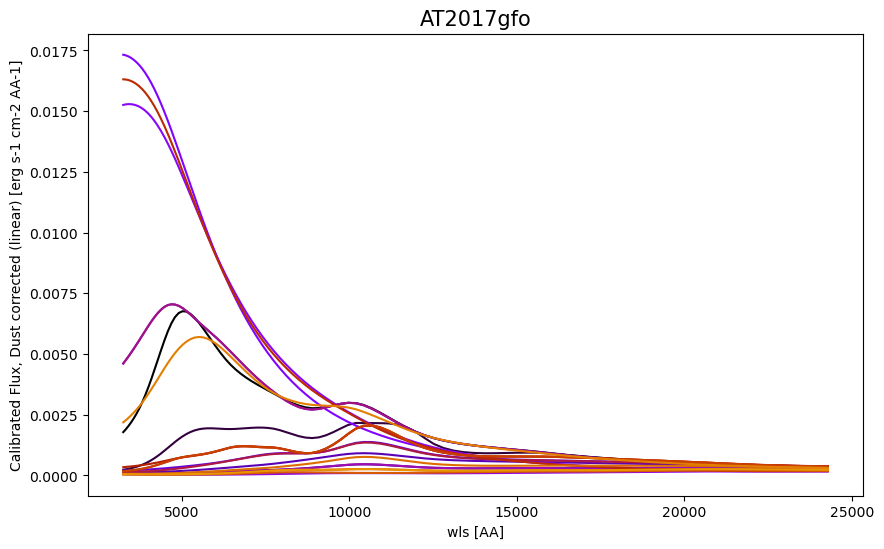

In [12]:
# FINAL host-corrected column in *_FINAL_spec.txt = linear F_lambda (not log10); y-scale accordingly.
def _path_FINAL_hostcorr(obj, l):
    """Primary: stem name matches TwoD extended (0.16..._FINAL_spec). Legacy: mangle spec_mjd filename."""
    base = obj.FINALspec_path
    p_stem = base + l.replace('spec_extended', 'FINAL_spec')
    if os.path.isfile(p_stem):
        return p_stem
    mpath = obj.results_mainpath + 'fitted_phot4mangling_%s.dat' % obj.snname
    if not os.path.isfile(mpath):
        return p_stem
    phot = pd.read_csv(mpath, sep='\t')
    fk = float(convert2mjd(l))
    n = len(phot)
    m = np.zeros(n, dtype=bool)
    if 'ext_grid_phase' in phot.columns:
        v = phot['ext_grid_phase'].values.astype(float)
        m |= np.isclose(v, fk, rtol=0.0, atol=1e-3, equal_nan=True)
        m |= np.isclose(np.round(v, 6), np.round(fk, 6), rtol=0.0, atol=0.0, equal_nan=True)
    sm = phot['spec_mjd'].values.astype(float)
    m |= sm == fk
    m |= np.isclose(sm, fk, rtol=0.0, atol=1e-3, equal_nan=True)
    if (not m.any()) and 'spec_log_phase' in phot.columns:
        slp = phot['spec_log_phase'].values.astype(float)
        m |= np.isclose(slp, fk, rtol=0.0, atol=1e-3, equal_nan=True)
    if m.any():
        smjd = float(phot.loc[m, 'spec_mjd'].values[0])
        p_mjd = base + '/%.6f_FINAL_spec.txt' % smjd
        if os.path.isfile(p_mjd):
            return p_mjd
    return p_stem

color = cycle(plt.cm.gnuplot(np.linspace(0,1,int(len(new_spec.get_spec_list())*1.2))))
fig = plt.figure(1, figsize=(10,6))
plt.title(new_spec.snname, fontsize=15)
mean, a = 1., 0
for l in new_spec.get_spec_list()[:]:
    new_spec.create_FINALspec_folder()
    pfin = _path_FINAL_hostcorr(new_spec, l)
    if not os.path.isfile(pfin):
        print('Missing FINAL:', pfin)
        continue
    sp = np.genfromtxt(pfin)
    plt.plot(sp[:,0], sp[:,1], lw=1.5, color=next(color))
    if mean == 1.:
        mean = np.median(sp[:,1]) * 0.2
    a = a + 1

plt.ylabel('Calibrated Flux, Dust corrected (linear) [erg s-1 cm-2 AA-1]')
plt.xlabel('wls [AA]')
plt.autoscale(True)
fig.savefig(new_spec.FINALspec_path + 'Final_Spec.png', bbox_inches='tight')
plt.show()
plt.close()

### SECOND: Remangle the "artificial" spectra (i.e. spectra that we extrapolated from the 2dim surface @phases were spectroscopy was too sparse)

In [13]:
#try for KN
new_spec = ReMangle_SingleSpectrumClass(
    snname=snname, twodim=True, spec_file=None, verbose=True
)
flagged_list = new_spec.get_FLAGGED_spec_list()
remangle_failed = []
remangle_diag_log_flagged = []
for f in flagged_list:
    new_spec = ReMangle_SingleSpectrumClass(
        snname=snname, twodim=True, spec_file=f, verbose=True
    )
    new_spec.load_extended_spec()
    result = new_spec.mangle_iteration_function()
    remangle_diag_log_flagged.append(getattr(new_spec, "remangle_diagnostics", None))
    if not result:
        remangle_failed.append(f)
        continue
    new_spec.save_FINAL_spectrum()
print("=" * 72)
n_flag = len(flagged_list)
print(
    "Re-mangle summary: %d / %d FLAGGED spectra could not be re-mangled (no in-MJD overlap)."
    % (len(remangle_failed), n_flag)
)
if remangle_failed:
    for _f in remangle_failed:
        print("  skipped:", _f)
print("=" * 72)

print_remangle_batch_summary(
    '"artificial" / FLAGGED extended spectra (get_FLAGGED_spec_list)',
    remangle_diag_log_flagged,
)


Choose one spec_file from this list:
['0.165363_spec_extended.txt', '0.387568_spec_extended.txt', '0.873437_spec_extended.txt', '0.736556_spec_extended.txt', '0.647970_spec_extended.txt', '0.158665_spec_extended.txt', '-0.309582_spec_extended.txt', '-0.274105_spec_extended.txt', '1.020030_spec_extended.txt', '0.872381_spec_extended.txt', '0.158664_spec_extended.txt', '0.653898_spec_extended.txt', '0.539351_spec_extended.txt', '-0.293965_spec_extended.txt', '0.537315_spec_extended.txt', '0.537316_spec_extended.txt', '0.927986_spec_extended.txt', '0.976442_spec_extended.txt', '0.810367_spec_extended.txt', '0.181958_spec_extended.txt', '0.927249_spec_extended.txt']
self.spec_file 1.209050_spec_extended_FL.txt
[DEBUG] Starting mangling for: 1.209050_spec_extended_FL.txt
[DEBUG] Calling calculate_ratios4mangling (initial)
ratios 3
[DEBUG] Calling GP_interpolation_mangle (initial)
ratios: [0.52116529 0.49570186 0.53836896]
ratios normed: [ 0.00531094 -0.04380719  0.03849625]
ratios err: [0.0

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/2222211348.py:520: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/2222211348.py:523: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2,


ratios 3
[remangle-iter] state=1 max|ratio-1|=0.037552 mask_min=0.99877 mask_max=1.0037
[DEBUG] Finished iteration 0
[DEBUG] Calling calculate_ratios4mangling...
ratios 3
[DEBUG] Calling GP_interpolation_mangle...
ratios: [1.01191926 0.96244831 1.03474917]
ratios normed: [ 0.00885344 -0.04046763  0.03161419]
ratios err: [0.11565978 0.08100053 0.32231552]
ratios err normed: [0.11530936 0.08075512 0.321339  ]
mean: 1.0030389158270776
ConstantKernel(log_constant=-7.0074028223791975, ndim=1, axes=array([0])) * Matern32Kernel(metric=Metric(0.3, ndim=1, axes=array([0]), bounds=[(None, None)]), block=None)
wls_eff_normedT: [2.40850412 2.38970416 1.00651462]
[DEBUG] Applying mangling mask to spectrum...
[DEBUG] Saving mangled spectrum and errors...
[DEBUG] Calculating band fluxes...
[DEBUG] used_filters = ['FLAMINGOS-2_Ks' 'FourStar_Ks' 'VIMOS_z']
[DEBUG] Computing band_flux for filter: FLAMINGOS-2_Ks
[DEBUG] Computing band_flux for filter: FourStar_Ks
[DEBUG] Computing band_flux for filter: V

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/2222211348.py:520: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/2222211348.py:523: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2,
/opt/anaconda3/envs/SED_clean/lib/python3.12/site-packages/george/kernels.py:94: RuntimeWarning: divide by zero encountered in log
  log_constant = np.log(float(b)/self.ndim)
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide

ratios 25
[remangle-iter] state=0 max|ratio-1|=0.58383 mask_min=0.83952 mask_max=1.2053
[DEBUG] Calling calculate_ratios4mangling...
ratios 25
[DEBUG] Calling GP_interpolation_mangle...
ratios: [0.99912103 1.03079128 1.18050189 1.53224583 0.96379553 0.88990309
 0.416173   0.9328669  1.00578156 0.87661155 0.7505532  0.85058457
 0.86636379 1.11861709 0.91826008 0.95536606 0.95517527 0.76118647
 1.08690422 0.99452    0.57299449 1.16016199 0.99554419 1.03715183
 1.15141941]
ratios normed: [ 0.04063858  0.07362486  0.22955656  0.5959169   0.00384517 -0.07311781
 -0.56653331 -0.02836868  0.04757588 -0.08696166 -0.21825826 -0.11407017
 -0.09763526  0.16510019 -0.04358247 -0.00493458 -0.00513331 -0.20718313
  0.13206952  0.03584636 -0.40319525  0.20837145  0.03691311  0.08024971
  0.19926559]
ratios err: [0.05124403 0.26902268 0.06309249 0.14835186 0.05039732 0.107313
 0.16724912 0.22197301 0.12216987 0.13929358 0.13267064 0.68871675
 0.11023863 0.14437846 0.0539389  0.13242384 0.10585425 0.19

...

ratios 8
[DEBUG] Calling GP_interpolation_mangle...
ratios: [0.9686247  1.1892936  1.01147868 0.81041343 0.96032926 1.20204123
 0.76622815 1.01241861]
ratios normed: [-0.02169345  0.20118114  0.02158888 -0.18148612 -0.0300718   0.21405619
 -0.22611304  0.02253821]
ratios err: [0.08440706 0.11875686 0.10268122 0.17122858 0.18142639 0.21406089
 0.15566333 0.05709441]
ratios err normed: [0.08525075 0.11994389 0.10370756 0.17294009 0.18323983 0.21620052
 0.15721926 0.0576651 ]
mean: 0.9901034594727436
ConstantKernel(log_constant=-3.835599190554449, ndim=1, axes=array([0])) * Matern32Kernel(metric=Metric(0.3, ndim=1, axes=array([0]), bounds=[(None, None)]), block=None)
wls_eff_normedT: [1.8187307  1.39069131 2.40971821 0.89391466 2.39136276 1.00840638
 1.39751627 2.39953169]
[DEBUG] Applying mangling mask to spectrum...
[DEBUG] Saving mangled spectrum and errors...
[DEBUG] Calculating band fluxes...
[DEBUG] used_filters = ['FLAMINGOS-2_H' 'FLAMINGOS-2_J' 'FLAMINGOS-2_Ks' 'FORS2_I' 'FourStar

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/2222211348.py:520: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/2222211348.py:523: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2,


ratios 40
[remangle-iter] state=0 max|ratio-1|=1.038 mask_min=0.38554 mask_max=1.0171
[DEBUG] Calling calculate_ratios4mangling...
ratios 40
[DEBUG] Calling GP_interpolation_mangle...
ratios: [0.94423128 1.16228491 1.08595412 1.00193961 0.61157681 0.88360017
 1.07366479 0.96460872 0.89827953 1.02608992 1.1059338  1.05722011
 1.18043411 0.86629704 0.93498698 1.01698496 0.97596585 0.9629691
 1.46319617 0.86556389 1.01912124 0.81508174 0.86827186 1.14003615
 0.93764507 1.02936556 1.34192239 1.0738699  0.98608633 0.98788018
 1.15920058 1.08847828 1.25287475 1.14797199 2.03797647 1.05570416
 1.15622741 0.98800115 0.96588953 1.11987622]
ratios normed: [-1.06122262e-01  1.00303106e-01  2.80428520e-02 -5.14913758e-02
 -4.21037079e-01 -1.63520062e-01  1.64088838e-02 -8.68314917e-02
 -1.49623511e-01 -2.86289398e-02  4.69570669e-02  8.41150892e-04
  1.17484453e-01 -1.79900454e-01 -1.14873577e-01 -3.72483563e-02
 -7.60800141e-02 -8.83836822e-02  3.85167507e-01 -1.80594504e-01
 -3.52259964e-02 -2.2

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/2222211348.py:520: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_72072/2222211348.py:523: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2,


ratios 6
[DEBUG] Calling GP_interpolation_mangle...
ratios: [0.82716894 0.99089836 1.01322403 1.09039404 1.07073831 0.94586073]
ratios normed: [-0.16423444  0.0011966   0.0237543   0.10172632  0.08186631 -0.0443091 ]
ratios err: [0.16598615 0.17948612 0.06037273 0.07510708 0.2332348  0.06592474]
ratios err normed: [0.16771122 0.18135149 0.06100017 0.07588765 0.23565876 0.06660989]
mean: 0.9897140695440118
ConstantKernel(log_constant=-4.858938697813277, ndim=1, axes=array([0])) * Matern32Kernel(metric=Metric(0.3, ndim=1, axes=array([0]), bounds=[(None, None)]), block=None)
wls_eff_normedT: [1.82051133 2.41186131 2.39381149 2.4164094  1.00662885 2.40174611]
[DEBUG] Applying mangling mask to spectrum...
[DEBUG] Saving mangled spectrum and errors...
[DEBUG] Calculating band fluxes...
[DEBUG] used_filters = ['FLAMINGOS-2_H' 'FLAMINGOS-2_Ks' 'FourStar_Ks' 'SOFI_Ks' 'VIMOS_z'
 'VISTA_Ks']
[DEBUG] Computing band_flux for filter: FLAMINGOS-2_H
[DEBUG] Computing band_flux for filter: FLAMINGOS-2

In [ ]:
import os
new_spec.create_FINALspec_folder()
missing_final = []
_remap_ok = True
try:
    _remangle_failed = set(remangle_failed)
    _flagged = list(flagged_list)
except NameError:
    _remap_ok = False
    _remangle_failed = set()
    _flagged = new_spec.get_FLAGGED_spec_list()[:]
    print("Note: 'flagged_list' / 'remangle_failed' not in scope. "
          "Re-run the FLAGGED re-mangle cell so only successful re-mangles are listed as 'plotted' vs 'not plotted'.")

plot_list = [f for f in _flagged if f not in _remangle_failed]
if (not _remap_ok) and plot_list:
    # Only use extended names that have a matching FINAL on disk
    _exists = []
    for f in plot_list:
        pth = os.path.join(
            new_spec.FINALspec_path,
            f.replace("_spec_extended_FL.txt", "_FINAL_spec_FL.txt"),
        )
        if os.path.exists(pth):
            _exists.append(f)
    plot_list = _exists

nplt = max(1, len(plot_list))
color = cycle(plt.cm.gnuplot(np.linspace(0, 1, int(nplt * 1.2))))
fig = plt.figure(1, figsize=(10, 6))
plt.title(snname + " ARTIFICIAL", fontsize=15)
mean = 1.0
a = 0
for l in plot_list:
    final_name = l.replace("_spec_extended_FL.txt", "_FINAL_spec_FL.txt")
    pth = os.path.join(new_spec.FINALspec_path, final_name)
    if not os.path.exists(pth):
        missing_final.append(l)
        continue
    sp = np.genfromtxt(pth)
    plt.plot(
        sp[:, 0], sp[:, 1],
        lw=1.5, color=next(color),
    )
    if mean == 1.0:
        mean = np.median(sp[:, 1]) * 0.2
plt.ylabel("Calibrated Flux, Dust corrected [erg s-1 cm-2 AA-1]")
plt.xlabel("wls [AA]")
#plt.ylim(0, 10)
plt.autoscale(True)
fig.savefig(new_spec.FINALspec_path + "Final_Spec_FL.png", bbox_inches="tight")
plt.show()
plt.close()
not_plotted = []
if _remap_ok:
    for f in _remangle_failed:
        not_plotted.append(f)
    not_plotted.extend(missing_final)
else:
    for f in _flagged:
        p = os.path.join(
            new_spec.FINALspec_path,
            f.replace("_spec_extended_FL.txt", "_FINAL_spec_FL.txt"),
        )
        if not os.path.exists(p):
            not_plotted.append(f)
    not_plotted.extend(missing_final)
if not_plotted:
    from collections import OrderedDict
    uniq = list(OrderedDict.fromkeys(not_plotted))
    print("=" * 72)
    print("Not plotted (%d file(s), re-mangle skipped and/or no FINAL on disk):" % len(uniq))
    for fn in uniq:
        print(" ", fn)
    print("=" * 72)
elif len(plot_list) == 0:
    print("No FINAL Spec FL curves to plot (check re-mangle outputs).")
else:
    print("Plotted %d curve(s) (all entries from the re-mangle success list had a FINAL file)." % len(plot_list))


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [ ]:


def create_lookup_table(data_dir, wavelength_range=None, wavelength_bins=10000):
    """
    Load spectra data from files, interpolate onto a common wavelength grid,
    and create a lookup table (DataFrame) for flux values.

    Parameters:
    - data_dir: str, path to the directory containing spectra files.
    - wavelength_range: tuple, min and max wavelength range for interpolation.
    - wavelength_bins: int, number of bins for wavelength interpolation.

    Returns:
    - lookup_table: pd.DataFrame, fluxes indexed by time and columns as wavelengths.
    - days_from_start: np.ndarray, time in days from the first MJD.
    - common_wavelengths: np.ndarray, the interpolated wavelength grid.
    """
    # Collect all spectra files
    spectra_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".txt")])

    # Lists to store results
    mjds = []
    wavelengths = []
    fluxes = []

    # Loop through all spectra files
    for file in spectra_files:
        # Extract the MJD from the filename (assuming it starts with MJD)
        mjd = float(file.split("_")[0])
        mjds.append(mjd)

        # Load the data (assuming 3 columns: wavelength, flux, flux error)
        data = np.loadtxt(os.path.join(data_dir, file))
        wavelengths.append(data[:, 0])  # First column: wavelength
        fluxes.append(data[:, 1])       # Second column: flux

    # Convert lists to numpy arrays for easier handling
    mjds = np.array(mjds)
    wavelengths = np.array(wavelengths, dtype=object)  # Allow variable-length arrays
    fluxes = np.array(fluxes, dtype=object)

    # Define a common wavelength grid
    #common_wavelengths = np.linspace(wavelength_range[0], wavelength_range[1], wavelength_bins)
    all_wavelengths = np.concatenate(wavelengths)
    wl_min = np.nanmin(all_wavelengths)
    wl_max = np.nanmax(all_wavelengths)
    common_wavelengths = np.linspace(wl_min, wl_max, wavelength_bins)

    # Interpolate flux onto the common wavelength grid
    fluxes_interpolated = []
    for i in range(len(fluxes)):
        flux_interp = np.interp(common_wavelengths, wavelengths[i], fluxes[i], left=np.nan, right=np.nan)
        fluxes_interpolated.append(flux_interp)

    fluxes_interpolated = np.array(fluxes_interpolated)

    # Subtract the minimum MJD to get days from start
    days_from_start = mjds - mjds.min()

    # Create a pandas DataFrame for lookup
    lookup_table = pd.DataFrame(
        fluxes_interpolated,
        index=days_from_start,  # Time as index (days from start)
        columns=common_wavelengths  # Wavelength as columns
    )

    return lookup_table, days_from_start, common_wavelengths


def plot_spectrum(time_from_start, lookup_table, wavelengths):
    """
    Plot a spectrum (flux vs wavelength) for a given time.
    """
    # Find the closest time in the DataFrame
    closest_time = lookup_table.index[np.argmin(np.abs(lookup_table.index - time_from_start))]
    flux = lookup_table.loc[closest_time]

    # Plot the spectrum
    plt.figure(figsize=(8, 5))
    plt.plot(wavelengths, flux, label=f"Time = {closest_time:.2f} days")
    plt.xlabel("Wavelength (Å)")
    plt.ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    plt.title("Spectrum at Time {:.2f} days".format(closest_time))
    plt.legend()
    plt.grid()
    plt.show()


def plot_lightcurve(wavelength, lookup_table):
    """
    Plot a light curve (flux vs time) for a given wavelength.
    """
    # Find the closest wavelength in the DataFrame
    closest_wavelength = lookup_table.columns[np.argmin(np.abs(lookup_table.columns - wavelength))]
    flux = lookup_table[closest_wavelength]

    # Plot the light curve
    plt.figure(figsize=(8, 5))
    plt.scatter(lookup_table.index, flux, label=f"Wavelength = {closest_wavelength:.2f} Å")
    plt.xlabel("Time (days from start)")
    plt.ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    plt.title("Lightcurve at Wavelength {:.2f} Å".format(closest_wavelength))
    plt.legend()
    plt.grid()
    plt.show()


def plot_sed_evolution(lookup_table, common_wavelengths, days_from_start, vmin=3.321846586518659e-05, vmax=0.04521411733143501):
    """
    Create a 2D plot of spectral density evolution (time vs wavelength vs flux).

    Parameters:
    - lookup_table: pd.DataFrame, flux values with time as index and wavelengths as columns.
    - common_wavelengths: np.ndarray, the wavelength grid used for interpolation.
    - days_from_start: np.ndarray, the time in days from the first detection.
    - vmin: float, minimum flux value for color scaling.
    - vmax: float, maximum flux value for color scaling.
    """
    plt.figure(figsize=(10, 6))
    plt.imshow(
        lookup_table.values.T, 
        aspect='auto', 
        extent=[days_from_start.min(), days_from_start.max(), common_wavelengths.min(), common_wavelengths.max()],
        origin='lower', 
        cmap='viridis', 
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    plt.colorbar(label=r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    plt.xlabel("Days from first detection")
    plt.ylabel("Wavelength (Å)")
    plt.title("SED Evolution")
    plt.show()



try my wavelength & time lookup code on kilonova:

In [ ]:
# Directory containing your spectra files (matches TWODIM_* / final_spectra_path_2dim in cell 1)
data_dir = final_spectra_path_2dim('AT2017gfo').rstrip(os.sep)

# Collect all files in the directory
spectra_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".txt")])

# Lists to store results
mjds = []
wavelengths = []
fluxes = []

# Loop through all spectra files
for file in spectra_files:
    # Extract the MJD from the filename (assuming it starts with MJD)
    mjd = float(file.split("_")[0])
    mjds.append(mjd)

    # Load the data (assuming 3 columns: wavelength, flux, flux error)
    data = np.loadtxt(os.path.join(data_dir, file))
    wavelengths.append(data[:, 0])  # First column: wavelength
    fluxes.append(data[:, 1])       # Second column: flux

# Convert lists to numpy arrays for easier handling
mjds = np.array(mjds)
wavelengths = np.array(wavelengths, dtype=object)  # Allow variable-length arrays
fluxes = np.array(fluxes, dtype=object)

# Define a common wavelength grid (e.g., union or interpolation grid)
#common_wavelengths = np.linspace(2000, 10000, 500)  # Adjust wavelength range and resolution
all_wavelengths = np.concatenate(wavelengths)
wl_min = np.nanmin(all_wavelengths)
wl_max = np.nanmax(all_wavelengths)
common_wavelengths = np.linspace(wl_min, wl_max, 500)
# Interpolate flux onto the common wavelength grid
fluxes_interpolated = []
for i in range(len(fluxes)):
    flux_interp = np.interp(common_wavelengths, wavelengths[i], fluxes[i], left=np.nan, right=np.nan)
    fluxes_interpolated.append(flux_interp)

fluxes_interpolated = np.array(fluxes_interpolated)

# Create a 2D plot
plt.figure(figsize=(10, 6))
plt.imshow(
    fluxes_interpolated.T, 
    aspect='auto', 
    extent=[mjds.min(), mjds.max(), common_wavelengths.min(), common_wavelengths.max()],
    origin='lower', 
    cmap='viridis', 
    norm=LogNorm(vmin=3.321846586518659e-05, vmax=0.04521411733143501)  # Adjust vmin/vmax as needed
)
#plt.colorbar(label=r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
plt.colorbar(label=r"Flux")
plt.xlabel("Days (MJD)")
plt.ylabel("Wavelength (Å)")
plt.title("SED Evolution")
plt.show()

In [ ]:
# Example Usage:
# Path to directory with spectra files
data_dir = final_spectra_path_2dim('AT2017gfo').rstrip(os.sep)

# Create the lookup table
lookup_table, days_from_start, common_wavelengths = create_lookup_table(data_dir)

In [ ]:
# Plot a light curve at 5000 Å
plot_lightcurve(17500, lookup_table)

In [ ]:
# Plot a spectrum at 20 days from start
plot_spectrum(3, lookup_table, common_wavelengths)

In [ ]:

plot_sed_evolution(lookup_table, common_wavelengths, days_from_start)